In [1]:

import sqlite3

conn = sqlite3.connect('emobility copy.db')

In [2]:
import pandas as pd

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

In [3]:
tables

,name
0,e_mobility_data_template_sow_4.1
1,kenya_ev_stations_(1)
2,e_mobility_data_template_sow_4_1
3,for_publication_africa_ev_readiness_impact_ind...
4,unep_eac_emobility_gantt_chart
5,unep_eac_emobility_weekly_live_chart
6,battery_eol
7,country_qualitative
8,eac_countries
9,financing


In [4]:
bat = pd.read_sql("""SELECT * FROM battery_eol""", conn)
bat.head()

,country_iso,year,battery_chemistry,volume_units,collection_rate_pct,recycling_facility_count,regulatory_status,data_source,notes
0,KE,2024,LFP,5000,10,1,draft,EPRA,No formal EPR
1,KE,2024,lead_acid,15000,45,3,enacted,NEMA,Legacy ICE batteries
2,RW,2024,LFP,3000,15,1,draft,REMA,NaN
3,RW,2024,lead_acid,8000,40,2,enacted,REMA,Legacy ICE batteries
4,UG,2024,lead_acid,12000,35,2,absent,NEMA,Legacy ICE batteries


In [5]:
bat.columns

Index(['country_iso', 'year', 'battery_chemistry', 'volume_units',
       'collection_rate_pct', 'recycling_facility_count', 'regulatory_status',
       'data_source', 'notes'],
      dtype='str')

In [6]:
country_q = pd.read_sql("""SELECT * FROM country_qualitative""", conn)
country_q.head()

,country_iso,country_name,ev_market_stage,primary_segment,charging_infrastructure,data_availability,key_barrier,key_opportunity,notes
0,TZ,Tanzania,Early growth,2W and 3W,Sparse but expanding,Low,Registration enforcement gap,Urban 2W electrification,10k+ estimate; EWURA guidelines 2026
1,BI,Burundi,Nascent,All,Minimal,NaN,No grid access,Policy framework in place,ICE import ban planned 2027
2,SS,South Sudan,Nascent,All,NaN,NaN,No grid access,Hybrid bridge,Hybrids preferred; no EV policy
3,CD,DR Congo,Nascent,All,Minimal,NaN,No grid access,Hydro-powered charging,No EV policy; SNEL grid mostly hydro
4,SO,Somalia,Nascent,All,NaN,NaN,No grid access,Private sector imports,Small-scale importers; no government policy


In [7]:
country_q.columns

Index(['country_iso', 'country_name', 'ev_market_stage', 'primary_segment',
       'charging_infrastructure', 'data_availability', 'key_barrier',
       'key_opportunity', 'notes'],
      dtype='str')

In [8]:
eac = pd.read_sql("""SELECT * FROM eac_countries""", conn)
eac.head()

,country_iso,country_name,eac_partner_state,accession_year,population,gdp_usd,currency_code,notes
0,KE,Kenya,1,2000,55100586,113400000000,KES,Founding member
1,RW,Rwanda,1,2007,14100000,14100000000,RWF,NaN
2,UG,Uganda,1,2000,48600000,49200000000,UGX,Founding member
3,TZ,Tanzania,1,2000,67400000,79100000000,TZS,Founding member
4,BI,Burundi,1,2007,13200000,3000000000,BIF,NaN


In [9]:
eac.columns

Index(['country_iso', 'country_name', 'eac_partner_state', 'accession_year',
       'population', 'gdp_usd', 'currency_code', 'notes'],
      dtype='str')

In [10]:
fis = pd.read_sql("""SELECT * FROM fiscal_tariffs""", conn)
fis.head()

,country_iso,year,vehicle_segment,duty_rate_ice,duty_rate_ev,vat_rate_ice,vat_rate_ev,data_source,notes
0,KE,2024,all,25.0,10.0,16.0,0.0,Kenya Gazette,NaN
1,RW,2024,all,25.0,0.0,18.0,0.0,RRA,NaN
2,UG,2024,all,25.0,0.0,18.0,0.0,URA,NaN
3,TZ,2024,all,25.0,10.0,18.0,0.0,TRA,NaN
4,BI,2024,all,NaN,NaN,NaN,NaN,OBR,VAT and customs exempt


In [11]:
fis.columns

Index(['country_iso', 'year', 'vehicle_segment', 'duty_rate_ice',
       'duty_rate_ev', 'vat_rate_ice', 'vat_rate_ev', 'data_source', 'notes'],
      dtype='str')

In [12]:
ind = pd.read_sql("""SELECT * FROM industrial_value_chain""", conn)
ind.head()

,country_iso,year,value_chain_stage,company_name,capacity_units_year,employment_count,year_established,local_content_pct,data_source,notes
0,KE,2024,assembly,ROAM Motors,5000.0,250.0,2017.0,15.0,ROAM,NaN
1,KE,2024,assembly,Arc Ride,3000.0,150.0,2020.0,12.0,Arc Ride,NaN
2,KE,2024,battery,Powerhive,2000.0,120.0,2015.0,10.0,Powerhive,NaN
3,RW,2024,assembly,Ampersand,10000.0,400.0,2016.0,20.0,Ampersand,NaN
4,RW,2024,assembly,Volt Rwanda,2000.0,100.0,2019.0,15.0,Volt Rwanda,NaN


In [13]:
ind.columns

Index(['country_iso', 'year', 'value_chain_stage', 'company_name',
       'capacity_units_year', 'employment_count', 'year_established',
       'local_content_pct', 'data_source', 'notes'],
      dtype='str')

In [14]:
mar = pd.read_sql("""SELECT * FROM market_fleet""", conn)
mar.head()

,country_iso,year,vehicle_segment,propulsion_type,new_registrations,cumulative_stock,data_source,data_confidence,notes
0,KE,2020,all,BEV,NaN,300.0,EPRA,high,Baseline
1,KE,2021,all,BEV,NaN,584.0,EPRA,high,NaN
2,KE,2022,all,BEV,NaN,1059.0,EPRA,high,NaN
3,KE,2023,all,BEV,NaN,3753.0,EPRA,high,NaN
4,KE,2024,all,BEV,NaN,5294.0,EPRA,high,NaN


In [15]:
mar.columns

Index(['country_iso', 'year', 'vehicle_segment', 'propulsion_type',
       'new_registrations', 'cumulative_stock', 'data_source',
       'data_confidence', 'notes'],
      dtype='str')

In [16]:
pol = pd.read_sql("""SELECT * FROM policy_inventory""", conn)
pol.head()

,country_iso,year,enacted_policy_instrument,instrument_type,category,status,effective_date,vehicle_segment,description,data_source
0,KE,2023,Finance Act 2023 EV VAT Exemption,fiscal,VAT,enacted,2023-07-01,all,Exempts EVs from 16% VAT,Kenya Gazette
1,KE,2023,Finance Act 2023 EV Duty Reduction,fiscal,import_duty,enacted,2023-07-01,all,Reduces EV import duty from 25% to 10%,Kenya Gazette
2,KE,2024,National E-Mobility Policy,regulatory,target,draft,2024-01-01,all,5% EV adoption by 2030,MoR&T
3,KE,2024,EPRA Charging Infrastructure Guidelines,regulatory,standard,enacted,2024-03-01,all,Technical standards for charging stations,EPRA
4,RW,2024,Rwanda EV Incentive Framework,fiscal,VAT,enacted,2024-01-01,all,EVs exempt from VAT and import duty,RRA


In [17]:
pol.columns

Index(['country_iso', 'year', 'enacted_policy_instrument', 'instrument_type',
       'category', 'status', 'effective_date', 'vehicle_segment',
       'description', 'data_source'],
      dtype='str')

In [18]:
print(pol.shape)
print(pol.columns.tolist())
print(pol.head())

(22, 10)
['country_iso', 'year', 'enacted_policy_instrument', 'instrument_type', 'category', 'status', 'effective_date', 'vehicle_segment', 'description', 'data_source']
  country_iso  year                enacted_policy_instrument instrument_type  \
0          KE  2023        Finance Act 2023 EV VAT Exemption          fiscal   
1          KE  2023       Finance Act 2023 EV Duty Reduction          fiscal   
2          KE  2024               National E-Mobility Policy      regulatory   
3          KE  2024  EPRA Charging Infrastructure Guidelines      regulatory   
4          RW  2024            Rwanda EV Incentive Framework          fiscal   

      category   status effective_date vehicle_segment  \
0          VAT  enacted     2023-07-01             all   
1  import_duty  enacted     2023-07-01             all   
2       target    draft     2024-01-01             all   
3     standard  enacted     2024-03-01             all   
4          VAT  enacted     2024-01-01             all   



In [19]:
pol.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   country_iso                22 non-null     str  
 1   year                       22 non-null     str  
 2   enacted_policy_instrument  22 non-null     str  
 3   instrument_type            22 non-null     str  
 4   category                   22 non-null     str  
 5   status                     22 non-null     str  
 6   effective_date             22 non-null     str  
 7   vehicle_segment            22 non-null     str  
 8   description                22 non-null     str  
 9   data_source                22 non-null     str  
dtypes: str(10)
memory usage: 1.8 KB


In [20]:
pow = pd.read_sql("""SELECT * FROM power_systems""", conn)
pow.head()

,country_iso,year,installed_capacity_mw,generation_hydro_pct,generation_solar_pct,generation_wind_pct,generation_thermal_pct,generation_other_pct,national_access_rate,urban_access_rate,rural_access_rate,peak_demand_mw,reserve_margin_pct,grid_emission_factor,data_source
0,KE,2024,3100.5,35,25,15,20,5,76,95,55,2200,40,0.15,EPRA/KPLC
1,RW,2024,195.0,45,10,5,35,5,65,90,45,150,30,0.35,REG
2,UG,2024,1250.0,80,5,0,15,0,45,85,30,900,38,0.12,UETCL
3,TZ,2024,3000.0,40,5,2,50,3,40,80,25,2000,50,0.45,TANESCO
4,BI,2024,100.0,90,2,0,8,0,12,50,5,80,25,0.08,REGIDESO


In [21]:
pow.columns

Index(['country_iso', 'year', 'installed_capacity_mw', 'generation_hydro_pct',
       'generation_solar_pct', 'generation_wind_pct', 'generation_thermal_pct',
       'generation_other_pct', 'national_access_rate', 'urban_access_rate',
       'rural_access_rate', 'peak_demand_mw', 'reserve_margin_pct',
       'grid_emission_factor', 'data_source'],
      dtype='str')

## Data Cleaning


### Battery eol

In [22]:
bat

,country_iso,year,battery_chemistry,volume_units,collection_rate_pct,recycling_facility_count,regulatory_status,data_source,notes
0,KE,2024,LFP,5000,10,1,draft,EPRA,No formal EPR
1,KE,2024,lead_acid,15000,45,3,enacted,NEMA,Legacy ICE batteries
2,RW,2024,LFP,3000,15,1,draft,REMA,NaN
3,RW,2024,lead_acid,8000,40,2,enacted,REMA,Legacy ICE batteries
4,UG,2024,lead_acid,12000,35,2,absent,NEMA,Legacy ICE batteries


In [23]:
bat.shape

(5, 9)

In [24]:
bat.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   country_iso               5 non-null      str  
 1   year                      5 non-null      int64
 2   battery_chemistry         5 non-null      str  
 3   volume_units              5 non-null      int64
 4   collection_rate_pct       5 non-null      int64
 5   recycling_facility_count  5 non-null      int64
 6   regulatory_status         5 non-null      str  
 7   data_source               5 non-null      str  
 8   notes                     4 non-null      str  
dtypes: int64(4), str(5)
memory usage: 492.0 bytes


In [25]:
bat.describe()

,year,volume_units,collection_rate_pct,recycling_facility_count
count,5.0,5.000000,5.000000,5.00000
mean,2024.0,8600.000000,29.000000,1.80000
std,0.0,4929.503018,15.572412,0.83666
min,2024.0,3000.000000,10.000000,1.00000
25%,2024.0,5000.000000,15.000000,1.00000
50%,2024.0,8000.000000,35.000000,2.00000
75%,2024.0,12000.000000,40.000000,2.00000
max,2024.0,15000.000000,45.000000,3.00000


In [26]:
bat.isnull().sum()

country_iso                 0
year                        0
battery_chemistry           0
volume_units                0
collection_rate_pct         0
recycling_facility_count    0
regulatory_status           0
data_source                 0
notes                       1
dtype: int64

In [27]:
bat.fillna("unknown", inplace=True)


,country_iso,year,battery_chemistry,volume_units,collection_rate_pct,recycling_facility_count,regulatory_status,data_source,notes
0,KE,2024,LFP,5000,10,1,draft,EPRA,No formal EPR
1,KE,2024,lead_acid,15000,45,3,enacted,NEMA,Legacy ICE batteries
2,RW,2024,LFP,3000,15,1,draft,REMA,unknown
3,RW,2024,lead_acid,8000,40,2,enacted,REMA,Legacy ICE batteries
4,UG,2024,lead_acid,12000,35,2,absent,NEMA,Legacy ICE batteries


In [28]:
bat.isnull().sum()

country_iso                 0
year                        0
battery_chemistry           0
volume_units                0
collection_rate_pct         0
recycling_facility_count    0
regulatory_status           0
data_source                 0
notes                       0
dtype: int64

In [29]:
bat.to_csv("battery_eol_cleaned.csv", index=False)

## country_qualitative

In [30]:
country_q.shape

(5, 9)

In [31]:
country_q.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   country_iso              5 non-null      str  
 1   country_name             5 non-null      str  
 2   ev_market_stage          5 non-null      str  
 3   primary_segment          5 non-null      str  
 4   charging_infrastructure  3 non-null      str  
 5   data_availability        1 non-null      str  
 6   key_barrier              5 non-null      str  
 7   key_opportunity          5 non-null      str  
 8   notes                    5 non-null      str  
dtypes: str(9)
memory usage: 492.0 bytes


In [32]:
country_q.describe().T

,count,unique,top,freq
country_iso,5,5,TZ,1
country_name,5,5,Tanzania,1
ev_market_stage,5,2,Nascent,4
primary_segment,5,2,All,4
charging_infrastructure,3,2,Minimal,2
data_availability,1,1,Low,1
key_barrier,5,2,No grid access,4
key_opportunity,5,5,Urban 2W electrification,1
notes,5,5,10k+ estimate; EWURA guidelines 2026,1


In [33]:
country_q.isnull().sum()

country_iso                0
country_name               0
ev_market_stage            0
primary_segment            0
charging_infrastructure    2
data_availability          4
key_barrier                0
key_opportunity            0
notes                      0
dtype: int64

In [34]:
country_q = country_q.fillna({
    'charging_infrastructure': 'abscent',
    'data_availability': 'not available'
})


In [35]:
country_q.isnull().sum()

country_iso                0
country_name               0
ev_market_stage            0
primary_segment            0
charging_infrastructure    0
data_availability          0
key_barrier                0
key_opportunity            0
notes                      0
dtype: int64

In [36]:
country_q.to_csv("country_qualitative_cleaned.csv", index=False)

## eac countries

In [37]:
eac.shape

(8, 8)

In [38]:
eac.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   country_iso        8 non-null      str  
 1   country_name       8 non-null      str  
 2   eac_partner_state  8 non-null      int64
 3   accession_year     8 non-null      int64
 4   population         8 non-null      int64
 5   gdp_usd            8 non-null      int64
 6   currency_code      8 non-null      str  
 7   notes              5 non-null      str  
dtypes: int64(4), str(4)
memory usage: 644.0 bytes


In [39]:
eac.describe()

,eac_partner_state,accession_year,population,gdp_usd
count,8.0,8.000000,8.000000e+00,8.000000e+00
mean,1.0,2009.500000,4.123007e+07,4.286250e+10
std,0.0,9.942693,3.301481e+07,4.084748e+10
min,1.0,2000.000000,1.100000e+07,3.000000e+09
25%,1.0,2000.000000,1.387500e+07,9.650000e+09
50%,1.0,2007.000000,3.337000e+07,3.165000e+10
75%,1.0,2017.500000,5.817544e+07,6.995000e+10
max,1.0,2024.000000,1.023000e+08,1.134000e+11


In [40]:
eac.isnull().sum()

country_iso          0
country_name         0
eac_partner_state    0
accession_year       0
population           0
gdp_usd              0
currency_code        0
notes                3
dtype: int64

In [41]:
eac["notes"].unique()

<StringArray>
['Founding member', nan, 'Joined 2022', 'Joined 2024']
Length: 4, dtype: str

In [42]:
eac=eac.fillna({
    'notes': 'Member'
    })

In [43]:
eac['notes'].unique()

<StringArray>
['Founding member', 'Member', 'Joined 2022', 'Joined 2024']
Length: 4, dtype: str

In [44]:
eac.to_csv("eac_countries_cleaned.csv", index=False)

## fiscal_tariffs

In [45]:
fis.shape

(8, 9)

In [46]:
fis.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country_iso      8 non-null      str    
 1   year             8 non-null      int64  
 2   vehicle_segment  8 non-null      str    
 3   duty_rate_ice    4 non-null      float64
 4   duty_rate_ev     4 non-null      float64
 5   vat_rate_ice     4 non-null      float64
 6   vat_rate_ev      4 non-null      float64
 7   data_source      8 non-null      str    
 8   notes            4 non-null      str    
dtypes: float64(4), int64(1), str(4)
memory usage: 708.0 bytes


In [47]:
fis.describe()

,year,duty_rate_ice,duty_rate_ev,vat_rate_ice,vat_rate_ev
count,8.0,4.0,4.000000,4.0,4.0
mean,2024.0,25.0,5.000000,17.5,0.0
std,0.0,0.0,5.773503,1.0,0.0
min,2024.0,25.0,0.000000,16.0,0.0
25%,2024.0,25.0,0.000000,17.5,0.0
50%,2024.0,25.0,5.000000,18.0,0.0
75%,2024.0,25.0,10.000000,18.0,0.0
max,2024.0,25.0,10.000000,18.0,0.0


In [48]:
fis.isnull().sum()

country_iso        0
year               0
vehicle_segment    0
duty_rate_ice      4
duty_rate_ev       4
vat_rate_ice       4
vat_rate_ev        4
data_source        0
notes              4
dtype: int64

In [49]:
fis

,country_iso,year,vehicle_segment,duty_rate_ice,duty_rate_ev,vat_rate_ice,vat_rate_ev,data_source,notes
0,KE,2024,all,25.0,10.0,16.0,0.0,Kenya Gazette,NaN
1,RW,2024,all,25.0,0.0,18.0,0.0,RRA,NaN
2,UG,2024,all,25.0,0.0,18.0,0.0,URA,NaN
3,TZ,2024,all,25.0,10.0,18.0,0.0,TRA,NaN
4,BI,2024,all,NaN,NaN,NaN,NaN,OBR,VAT and customs exempt
5,SS,2024,all,NaN,NaN,NaN,NaN,Ministry of Transport,No EV-specific tariff
6,CD,2024,all,NaN,NaN,NaN,NaN,Ministry of Transport,No EV-specific tariff
7,SO,2024,all,NaN,NaN,NaN,NaN,Ministry of Transport,No EV-specific tariff


In [50]:
fis = fis.fillna({
    'duty_rate_ice': 'unknown',
    'duty_rate_ev': 'unknown',
    'vat_rate_ice': 'unknown',
    'vat_rate_ev': 'unknown',
    'notes': 'none'
},inplace=True)

In [51]:
fis.isnull().sum()

country_iso        0
year               0
vehicle_segment    0
duty_rate_ice      0
duty_rate_ev       0
vat_rate_ice       0
vat_rate_ev        0
data_source        0
notes              0
dtype: int64

In [52]:
fis.to_csv("fiscal_tariffs_cleaned.csv", index=False)

## industrial_value_chain

In [53]:
ind.shape

(11, 10)

In [54]:
ind.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country_iso          11 non-null     str    
 1   year                 11 non-null     int64  
 2   value_chain_stage    11 non-null     str    
 3   company_name         10 non-null     str    
 4   capacity_units_year  8 non-null      float64
 5   employment_count     8 non-null      float64
 6   year_established     8 non-null      float64
 7   local_content_pct    8 non-null      float64
 8   data_source          11 non-null     str    
 9   notes                2 non-null      str    
dtypes: float64(4), int64(1), str(5)
memory usage: 1012.0 bytes


In [55]:
ind.describe()

,year,capacity_units_year,employment_count,year_established,local_content_pct
count,11.000000,8.000000,8.000000,8.000000,8.000000
mean,2024.545455,4437.500000,196.250000,2017.500000,14.625000
std,0.934199,3245.188746,115.750656,2.976095,7.633339
min,2024.000000,500.000000,50.000000,2014.000000,0.000000
25%,2024.000000,2000.000000,115.000000,2015.750000,11.500000
50%,2024.000000,4000.000000,175.000000,2016.500000,15.000000
75%,2025.000000,5750.000000,262.500000,2019.250000,20.000000
max,2026.000000,10000.000000,400.000000,2023.000000,25.000000


In [56]:
ind.isnull().sum()

country_iso            0
year                   0
value_chain_stage      0
company_name           1
capacity_units_year    3
employment_count       3
year_established       3
local_content_pct      3
data_source            0
notes                  9
dtype: int64

In [57]:
ind

,country_iso,year,value_chain_stage,company_name,capacity_units_year,employment_count,year_established,local_content_pct,data_source,notes
0,KE,2024,assembly,ROAM Motors,5000.0,250.0,2017.0,15.0,ROAM,NaN
1,KE,2024,assembly,Arc Ride,3000.0,150.0,2020.0,12.0,Arc Ride,NaN
2,KE,2024,battery,Powerhive,2000.0,120.0,2015.0,10.0,Powerhive,NaN
3,RW,2024,assembly,Ampersand,10000.0,400.0,2016.0,20.0,Ampersand,NaN
4,RW,2024,assembly,Volt Rwanda,2000.0,100.0,2019.0,15.0,Volt Rwanda,NaN
5,UG,2024,assembly,Zembo,8000.0,300.0,2016.0,25.0,Zembo,NaN
6,UG,2024,assembly,Bodawerk,5000.0,200.0,2014.0,20.0,Bodawerk,NaN
7,UG,2024,recycling,NaN,500.0,50.0,2023.0,0.0,AfEMA,NaN
8,TZ,2026,assembly,Spiro,NaN,NaN,NaN,NaN,Daily News,NaN
9,TZ,2026,assembly,TankVolt,NaN,NaN,NaN,NaN,Daily News,Chinese subsidiary of Transsion Holdings


In [58]:
ind = ind.fillna({
    'capacity_units_year': '0',
    'employment_count':'0',
    'company_name':'unknown',
    'year_established':'0.0',
    'data_source':'unknown'
    
})

In [59]:
ind['year'] = ind['year'].astype(int).astype(str)
ind['year'] = pd.to_datetime(ind['year'], format='%Y')

In [60]:
ind.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   country_iso          11 non-null     str           
 1   year                 11 non-null     datetime64[us]
 2   value_chain_stage    11 non-null     str           
 3   company_name         11 non-null     str           
 4   capacity_units_year  11 non-null     object        
 5   employment_count     11 non-null     object        
 6   year_established     11 non-null     object        
 7   local_content_pct    8 non-null      float64       
 8   data_source          11 non-null     str           
 9   notes                2 non-null      str           
dtypes: datetime64[us](1), float64(1), object(3), str(5)
memory usage: 1012.0+ bytes


In [61]:
ind

,country_iso,year,value_chain_stage,company_name,capacity_units_year,employment_count,year_established,local_content_pct,data_source,notes
0,KE,2024-01-01,assembly,ROAM Motors,5000.0,250.0,2017.0,15.0,ROAM,NaN
1,KE,2024-01-01,assembly,Arc Ride,3000.0,150.0,2020.0,12.0,Arc Ride,NaN
2,KE,2024-01-01,battery,Powerhive,2000.0,120.0,2015.0,10.0,Powerhive,NaN
3,RW,2024-01-01,assembly,Ampersand,10000.0,400.0,2016.0,20.0,Ampersand,NaN
4,RW,2024-01-01,assembly,Volt Rwanda,2000.0,100.0,2019.0,15.0,Volt Rwanda,NaN
5,UG,2024-01-01,assembly,Zembo,8000.0,300.0,2016.0,25.0,Zembo,NaN
6,UG,2024-01-01,assembly,Bodawerk,5000.0,200.0,2014.0,20.0,Bodawerk,NaN
7,UG,2024-01-01,recycling,unknown,500.0,50.0,2023.0,0.0,AfEMA,NaN
8,TZ,2026-01-01,assembly,Spiro,0,0,0.0,NaN,Daily News,NaN
9,TZ,2026-01-01,assembly,TankVolt,0,0,0.0,NaN,Daily News,Chinese subsidiary of Transsion Holdings


In [62]:
ind.fillna({
    'notes': 'none',
    'local_content_pct': '0.0'
}, inplace=True)

,country_iso,year,value_chain_stage,company_name,capacity_units_year,employment_count,year_established,local_content_pct,data_source,notes
0,KE,2024-01-01,assembly,ROAM Motors,5000.0,250.0,2017.0,15.0,ROAM,none
1,KE,2024-01-01,assembly,Arc Ride,3000.0,150.0,2020.0,12.0,Arc Ride,none
2,KE,2024-01-01,battery,Powerhive,2000.0,120.0,2015.0,10.0,Powerhive,none
3,RW,2024-01-01,assembly,Ampersand,10000.0,400.0,2016.0,20.0,Ampersand,none
4,RW,2024-01-01,assembly,Volt Rwanda,2000.0,100.0,2019.0,15.0,Volt Rwanda,none
5,UG,2024-01-01,assembly,Zembo,8000.0,300.0,2016.0,25.0,Zembo,none
6,UG,2024-01-01,assembly,Bodawerk,5000.0,200.0,2014.0,20.0,Bodawerk,none
7,UG,2024-01-01,recycling,unknown,500.0,50.0,2023.0,0.0,AfEMA,none
8,TZ,2026-01-01,assembly,Spiro,0,0,0.0,0.0,Daily News,none
9,TZ,2026-01-01,assembly,TankVolt,0,0,0.0,0.0,Daily News,Chinese subsidiary of Transsion Holdings


In [63]:
ind.isnull().sum()

country_iso            0
year                   0
value_chain_stage      0
company_name           0
capacity_units_year    0
employment_count       0
year_established       0
local_content_pct      0
data_source            0
notes                  0
dtype: int64

In [64]:
ind.to_csv("industrial_value_chain_cleaned.csv", index=False)

## Market Fleet

In [65]:
mar.shape

(20, 9)

In [66]:
mar.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country_iso        20 non-null     str    
 1   year               20 non-null     int64  
 2   vehicle_segment    20 non-null     str    
 3   propulsion_type    20 non-null     str    
 4   new_registrations  7 non-null      float64
 5   cumulative_stock   19 non-null     float64
 6   data_source        20 non-null     str    
 7   data_confidence    20 non-null     str    
 8   notes              6 non-null      str    
dtypes: float64(2), int64(1), str(6)
memory usage: 1.5 KB


In [67]:
mar.describe()

,year,new_registrations,cumulative_stock
count,20.000000,7.000000,19.000000
mean,2022.750000,762.428571,2330.473684
std,1.831738,1560.879117,2916.874323
min,2020.000000,19.000000,19.000000
25%,2021.000000,23.500000,118.500000
50%,2023.000000,96.000000,584.000000
75%,2024.250000,450.500000,3576.500000
max,2025.000000,4274.000000,10000.000000


In [68]:
mar.isnull().sum()

country_iso           0
year                  0
vehicle_segment       0
propulsion_type       0
new_registrations    13
cumulative_stock      1
data_source           0
data_confidence       0
notes                14
dtype: int64

In [69]:
mar

,country_iso,year,vehicle_segment,propulsion_type,new_registrations,cumulative_stock,data_source,data_confidence,notes
0,KE,2020,all,BEV,NaN,300.0,EPRA,high,Baseline
1,KE,2021,all,BEV,NaN,584.0,EPRA,high,NaN
2,KE,2022,all,BEV,NaN,1059.0,EPRA,high,NaN
3,KE,2023,all,BEV,NaN,3753.0,EPRA,high,NaN
4,KE,2024,all,BEV,NaN,5294.0,EPRA,high,NaN
5,KE,2025,all,BEV,NaN,6442.0,EPRA,high,As of June 2025
6,RW,2020,passenger,BEV,19.0,19.0,RRA,high,NaN
7,RW,2021,passenger,BEV,19.0,38.0,RRA,high,NaN
8,RW,2021,passenger,HEV,28.0,28.0,RRA,high,NaN
9,RW,2022,passenger,BEV,96.0,134.0,RRA,high,NaN


In [70]:
mar.fillna({
    'new_registrations': 0,
    'cumulative_stock': 0,
    'notes': 'none'

},inplace=True)

,country_iso,year,vehicle_segment,propulsion_type,new_registrations,cumulative_stock,data_source,data_confidence,notes
0,KE,2020,all,BEV,0.0,300.0,EPRA,high,Baseline
1,KE,2021,all,BEV,0.0,584.0,EPRA,high,none
2,KE,2022,all,BEV,0.0,1059.0,EPRA,high,none
3,KE,2023,all,BEV,0.0,3753.0,EPRA,high,none
4,KE,2024,all,BEV,0.0,5294.0,EPRA,high,none
5,KE,2025,all,BEV,0.0,6442.0,EPRA,high,As of June 2025
6,RW,2020,passenger,BEV,19.0,19.0,RRA,high,none
7,RW,2021,passenger,BEV,19.0,38.0,RRA,high,none
8,RW,2021,passenger,HEV,28.0,28.0,RRA,high,none
9,RW,2022,passenger,BEV,96.0,134.0,RRA,high,none


In [71]:
mar.isnull().sum()

country_iso          0
year                 0
vehicle_segment      0
propulsion_type      0
new_registrations    0
cumulative_stock     0
data_source          0
data_confidence      0
notes                0
dtype: int64

In [72]:
mar.to_csv("market_fleet_cleaned.csv", index=False)

## Policy Inventory

In [73]:
pol.shape

(22, 10)

In [74]:
pol.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   country_iso                22 non-null     str  
 1   year                       22 non-null     str  
 2   enacted_policy_instrument  22 non-null     str  
 3   instrument_type            22 non-null     str  
 4   category                   22 non-null     str  
 5   status                     22 non-null     str  
 6   effective_date             22 non-null     str  
 7   vehicle_segment            22 non-null     str  
 8   description                22 non-null     str  
 9   data_source                22 non-null     str  
dtypes: str(10)
memory usage: 1.8 KB


In [75]:
pol.describe()

,country_iso,year,enacted_policy_instrument,instrument_type,category,status,effective_date,vehicle_segment,description,data_source
count,22,22,22,22,22,22,22,22,22,22
unique,8,5,19,2,8,6,10,2,20,16
top,KE,2024,No EV Policy,regulatory,target,enacted,,all,No dedicated EV policy framework,Ministry of Transport
freq,4,15,3,16,5,14,5,19,3,4


In [76]:
pol.isnull().sum()

country_iso                  0
year                         0
enacted_policy_instrument    0
instrument_type              0
category                     0
status                       0
effective_date               0
vehicle_segment              0
description                  0
data_source                  0
dtype: int64

In [77]:
pow.shape

(8, 15)

In [78]:
pow.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country_iso             8 non-null      str    
 1   year                    8 non-null      int64  
 2   installed_capacity_mw   8 non-null      float64
 3   generation_hydro_pct    8 non-null      int64  
 4   generation_solar_pct    8 non-null      int64  
 5   generation_wind_pct     8 non-null      int64  
 6   generation_thermal_pct  8 non-null      int64  
 7   generation_other_pct    8 non-null      int64  
 8   national_access_rate    8 non-null      int64  
 9   urban_access_rate       8 non-null      int64  
 10  rural_access_rate       8 non-null      int64  
 11  peak_demand_mw          8 non-null      int64  
 12  reserve_margin_pct      8 non-null      int64  
 13  grid_emission_factor    8 non-null      float64
 14  data_source             8 non-null      str    
dtypes: f

In [79]:
pol.to_csv("policy_inventory_cleaned.csv", index=False)

In [80]:
pow.describe()

,year,installed_capacity_mw,generation_hydro_pct,generation_solar_pct,generation_wind_pct,generation_thermal_pct,generation_other_pct,national_access_rate,urban_access_rate,rural_access_rate,peak_demand_mw,reserve_margin_pct,grid_emission_factor
count,8.0,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.00000,8.000000,8.000000,8.0000,8.000000,8.000000
mean,2024.0,1351.937500,48.125000,9.125000,3.375000,37.750000,1.625000,35.12500,66.250000,21.500000,918.7500,36.000000,0.331250
std,0.0,1416.668386,37.505952,7.918108,5.180665,32.796995,2.326094,25.60378,24.604007,20.549592,940.4017,13.763305,0.279154
min,2024.0,100.000000,0.000000,1.000000,0.000000,4.000000,0.000000,8.00000,30.000000,2.000000,80.0000,20.000000,0.050000
25%,2024.0,142.500000,26.250000,4.250000,0.000000,13.250000,0.000000,14.25000,47.500000,5.000000,115.0000,25.000000,0.110000
50%,2024.0,722.500000,42.500000,7.500000,1.000000,27.500000,0.000000,30.00000,70.000000,15.000000,525.0000,34.000000,0.250000
75%,2024.0,2925.000000,82.500000,11.250000,5.000000,57.500000,3.500000,50.00000,86.250000,33.750000,1850.0000,42.500000,0.512500
max,2024.0,3100.500000,95.000000,25.000000,15.000000,90.000000,5.000000,76.00000,95.000000,55.000000,2200.0000,60.000000,0.750000


In [81]:
pow.isnull().sum()

country_iso               0
year                      0
installed_capacity_mw     0
generation_hydro_pct      0
generation_solar_pct      0
generation_wind_pct       0
generation_thermal_pct    0
generation_other_pct      0
national_access_rate      0
urban_access_rate         0
rural_access_rate         0
peak_demand_mw            0
reserve_margin_pct        0
grid_emission_factor      0
data_source               0
dtype: int64

In [82]:
pow.to_csv("power_systems_cleaned.csv", index=False)

# Charging stations

In [83]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables

,name
0,e_mobility_data_template_sow_4.1
1,kenya_ev_stations_(1)
2,e_mobility_data_template_sow_4_1
3,for_publication_africa_ev_readiness_impact_ind...
4,unep_eac_emobility_gantt_chart
5,unep_eac_emobility_weekly_live_chart
6,battery_eol
7,country_qualitative
8,eac_countries
9,financing


In [84]:
kenya_charge = pd.read_sql("""SELECT * FROM kenya_ev_stations_1""", conn)
kenya_charge.head()

,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_model_supported,operating_hours,status,average_rating
0,Sarit Centre Hub A,EVChaja,Nairobi,"-1.2588, 36.8037",AC Type 2 (22kW),4,KSh 35/kWh,"M-Pesa, App","BYD Atto 3, Nissan Leaf, Tesla Model 3, Hyunda...",06:00 - 22:00,Operational,4.5
1,Two Rivers Mall Fast Charge,EVChaja,Nairobi,"-1.2131, 36.7925",DC CCS2 Fast (50kW),2,KSh 45/kWh,"M-Pesa, App, Card","BYD Atto 3, Nissan Leaf, Tesla Model 3, Hyunda...",24/7,Operational,4.7
2,Waterfront Mall Karen,Asaph Green Mobility,Nairobi,"-1.3411, 36.7166",AC Type 2 (22kW),2,KSh 40/kWh,"M-Pesa, App","BYD Atto 3, Nissan Leaf, Tesla Model 3, Hyunda...",07:00 - 21:00,Operational,4.2
3,Mega City Mall Kisumu,EVChaja,Kisumu,"-0.1062, 34.7705",AC Type 2 (22kW),2,KSh 35/kWh,"M-Pesa, App","BYD Atto 3, Nissan Leaf, Tesla Model 3, Hyunda...",08:00 - 20:00,Operational,4.0
4,City Mall Nyali,EVChaja,Mombasa,"-4.0194, 39.7289",AC Type 2 (22kW),2,KSh 35/kWh,"M-Pesa, App","BYD Atto 3, Nissan Leaf, Tesla Model 3, Hyunda...",08:00 - 22:00,Operational,4.3


In [85]:
kenya_charge.columns

Index(['station_name', 'provider', 'county_region', 'coordinates',
       'charger_types', 'number_of_ports', 'pricing', 'payment_methods',
       'car_model_supported', 'operating_hours', 'status', 'average_rating'],
      dtype='str')

In [86]:
kenya_charge_infrast= pd.read_sql("""SELECT * FROM kenya_ev_charging_infrastructure""", conn)
kenya_charge_infrast.head()

,station_name,provider,county,location,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,motorcycle_support,operating_hours,status,average_rating
0,Stima Plaza,Kenya Power,Nairobi,"Parklands, Nairobi","-1.2641, 36.8161","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",0,24/7,Operational,4.5
1,Ruaraka Depot,Kenya Power,Nairobi,"Ruaraka, Nairobi","-1.2567, 36.8833","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",0,24/7,Operational,4.3
2,Donholm Depot,Kenya Power,Nairobi,"Donholm, Nairobi","-1.2937, 36.9006","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",0,24/7,Operational,4.2
3,Ragati Depot,Kenya Power,Nairobi,"Ragati - Upperhill, Nairobi","-1.29558, 36.81281","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",0,24/7,Operational,4.1
4,TotalEnergies-Roam Hub Lusaka Road,TotalEnergies | Roam-electric,Nairobi,"Lusaka Road, Nairobi","-1.30124, 36.83284","22kW AC Charger, Battery Swap for motorcycles",2,KSh 20-50 per kWh (varies by time),"M-Pesa, Credit Card, Debit Card",Not available,1,24/7,Operational,4.3


In [87]:
kenya_charge_infrast.columns

Index(['station_name', 'provider', 'county', 'location', 'coordinates',
       'charger_types', 'number_of_ports', 'pricing', 'payment_methods',
       'car_models_supported', 'motorcycle_support', 'operating_hours',
       'status', 'average_rating'],
      dtype='str')

In [88]:
kenya_charge_infrast.drop(columns=['location', 'motorcycle_support'], inplace=True)



In [89]:
kenya_charge.isnull().sum()

station_name           0
provider               0
county_region          0
coordinates            0
charger_types          0
number_of_ports        0
pricing                0
payment_methods        0
car_model_supported    0
operating_hours        0
status                 0
average_rating         0
dtype: int64

In [90]:
kenya_charge_infrast.isnull().sum()

station_name            0
provider                0
county                  0
coordinates             0
charger_types           0
number_of_ports         0
pricing                 0
payment_methods         0
car_models_supported    0
operating_hours         0
status                  0
average_rating          4
dtype: int64

In [91]:
kenya_charge_infrast

,station_name,provider,county,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Stima Plaza,Kenya Power,Nairobi,"-1.2641, 36.8161","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.5
1,Ruaraka Depot,Kenya Power,Nairobi,"-1.2567, 36.8833","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.3
2,Donholm Depot,Kenya Power,Nairobi,"-1.2937, 36.9006","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.2
3,Ragati Depot,Kenya Power,Nairobi,"-1.29558, 36.81281","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.1
4,TotalEnergies-Roam Hub Lusaka Road,TotalEnergies | Roam-electric,Nairobi,"-1.30124, 36.83284","22kW AC Charger, Battery Swap for motorcycles",2,KSh 20-50 per kWh (varies by time),"M-Pesa, Credit Card, Debit Card",Not available,24/7,Operational,4.3
5,TotalEnergies-Roam Hub Waiyaki Way,TotalEnergies | Roam-electric,Nairobi,"-1.25789, 36.78216","22kW AC Charger, Battery Swap for motorcycles",2,KSh 20-50 per kWh,"M-Pesa, Credit Card, Debit Card",Not available at the hub,24/7,Operational,4.7
6,TotalEnergies - Ampersand Dagoretti Swap Station,TotalEnergies | Ampersand-energy,Nairobi,"-1.29547, 36.75867",Battery Swap for motorcycles,0,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,5.0
7,TotalEnergies - Ampersand Mountain View Swap S...,TotalEnergies | Ampersand-energy,Nairobi,"-1.26081, 36.73841",Battery Swap for motorcycles,0,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,0.0
8,TotalEnergies - Ampersand Starehe Swap Station,TotalEnergies | Ampersand-energy,Nairobi,"-1.27739, 36.83708",Battery Swap for motorcycles,3,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,5.0
9,TotalEnergies - Ampersand Hurlingham Swap Station,TotalEnergies | Ampersand-energy,Nairobi,"-1.28874, 36.80090",Battery Swap for motorcycles,3,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,1.0


In [92]:
kenya_charge_infrast.fillna({
    'average_rating': 0.0
},inplace = True)

,station_name,provider,county,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Stima Plaza,Kenya Power,Nairobi,"-1.2641, 36.8161","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.5
1,Ruaraka Depot,Kenya Power,Nairobi,"-1.2567, 36.8833","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.3
2,Donholm Depot,Kenya Power,Nairobi,"-1.2937, 36.9006","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.2
3,Ragati Depot,Kenya Power,Nairobi,"-1.29558, 36.81281","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.1
4,TotalEnergies-Roam Hub Lusaka Road,TotalEnergies | Roam-electric,Nairobi,"-1.30124, 36.83284","22kW AC Charger, Battery Swap for motorcycles",2,KSh 20-50 per kWh (varies by time),"M-Pesa, Credit Card, Debit Card",Not available,24/7,Operational,4.3
5,TotalEnergies-Roam Hub Waiyaki Way,TotalEnergies | Roam-electric,Nairobi,"-1.25789, 36.78216","22kW AC Charger, Battery Swap for motorcycles",2,KSh 20-50 per kWh,"M-Pesa, Credit Card, Debit Card",Not available at the hub,24/7,Operational,4.7
6,TotalEnergies - Ampersand Dagoretti Swap Station,TotalEnergies | Ampersand-energy,Nairobi,"-1.29547, 36.75867",Battery Swap for motorcycles,0,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,5.0
7,TotalEnergies - Ampersand Mountain View Swap S...,TotalEnergies | Ampersand-energy,Nairobi,"-1.26081, 36.73841",Battery Swap for motorcycles,0,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,0.0
8,TotalEnergies - Ampersand Starehe Swap Station,TotalEnergies | Ampersand-energy,Nairobi,"-1.27739, 36.83708",Battery Swap for motorcycles,3,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,5.0
9,TotalEnergies - Ampersand Hurlingham Swap Station,TotalEnergies | Ampersand-energy,Nairobi,"-1.28874, 36.80090",Battery Swap for motorcycles,3,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,1.0


In [93]:
kenya_charge_infrast.isnull().sum()

station_name            0
provider                0
county                  0
coordinates             0
charger_types           0
number_of_ports         0
pricing                 0
payment_methods         0
car_models_supported    0
operating_hours         0
status                  0
average_rating          0
dtype: int64

In [94]:
kenya_charge.info()

<class 'pandas.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   station_name         165 non-null    str    
 1   provider             165 non-null    str    
 2   county_region        165 non-null    str    
 3   coordinates          165 non-null    str    
 4   charger_types        165 non-null    str    
 5   number_of_ports      165 non-null    int64  
 6   pricing              165 non-null    str    
 7   payment_methods      165 non-null    str    
 8   car_model_supported  165 non-null    str    
 9   operating_hours      165 non-null    str    
 10  status               165 non-null    str    
 11  average_rating       165 non-null    float64
dtypes: float64(1), int64(1), str(10)
memory usage: 15.6 KB


In [95]:
kenya_charge_infrast.info()

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_name          29 non-null     str    
 1   provider              29 non-null     str    
 2   county                29 non-null     str    
 3   coordinates           29 non-null     str    
 4   charger_types         29 non-null     str    
 5   number_of_ports       29 non-null     int64  
 6   pricing               29 non-null     str    
 7   payment_methods       29 non-null     str    
 8   car_models_supported  29 non-null     str    
 9   operating_hours       29 non-null     str    
 10  status                29 non-null     str    
 11  average_rating        29 non-null     float64
dtypes: float64(1), int64(1), str(10)
memory usage: 2.8 KB


In [96]:
kenya_charge_infrast.rename(columns={'county': 'county_region'}, 
                            inplace=True)

In [97]:
kenya_charge.rename(columns={'car_model_supported': 'car_models_supported'}, 
                    inplace=True)

In [98]:
kenya_charge.columns

Index(['station_name', 'provider', 'county_region', 'coordinates',
       'charger_types', 'number_of_ports', 'pricing', 'payment_methods',
       'car_models_supported', 'operating_hours', 'status', 'average_rating'],
      dtype='str')

In [99]:
kenya_main = pd.read_sql("""SELECT * FROM kenya_ev_charging_stations""", conn)

In [100]:
kenya_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station name          215 non-null    str    
 1   provider              215 non-null    str    
 2   county/region         215 non-null    str    
 3   coordinates           215 non-null    str    
 4   charger types         215 non-null    str    
 5   number of ports       215 non-null    int64  
 6   pricing               215 non-null    str    
 7   payment methods       215 non-null    str    
 8   car models supported  215 non-null    str    
 9   operating hours       215 non-null    str    
 10  status                215 non-null    str    
 11  average rating        215 non-null    float64
dtypes: float64(1), int64(1), str(10)
memory usage: 20.3 KB


In [101]:
kenya_main.columns = kenya_main.columns.str.lower().str.replace(' ', '_')

In [102]:
kenya_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_name          215 non-null    str    
 1   provider              215 non-null    str    
 2   county/region         215 non-null    str    
 3   coordinates           215 non-null    str    
 4   charger_types         215 non-null    str    
 5   number_of_ports       215 non-null    int64  
 6   pricing               215 non-null    str    
 7   payment_methods       215 non-null    str    
 8   car_models_supported  215 non-null    str    
 9   operating_hours       215 non-null    str    
 10  status                215 non-null    str    
 11  average_rating        215 non-null    float64
dtypes: float64(1), int64(1), str(10)
memory usage: 20.3 KB


In [103]:
kenya_main.rename(columns={'county/region': 'county_region'}, inplace=True)

In [104]:
kenya_charge_infrast.columns

Index(['station_name', 'provider', 'county_region', 'coordinates',
       'charger_types', 'number_of_ports', 'pricing', 'payment_methods',
       'car_models_supported', 'operating_hours', 'status', 'average_rating'],
      dtype='str')

In [105]:
common_cols = [
    'station_name', 'provider', 'county_region', 'coordinates',
    'charger_types', 'number_of_ports', 'pricing', 'payment_methods',
    'car_models_supported', 'operating_hours', 'status', 'average_rating'
]

# Merge using all 12 columns as the composite key
kenya_ev_stations = pd.merge(kenya_main,kenya_charge_infrast, 
                             on=common_cols, how='left')

In [106]:
kenya_ev_stations.head(10)

,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Kenya Power (e-mobility) Hub - Central Hub #47,Kenya Power (e-mobility),Kajiado,"-0.77132, 36.3926",DC Fast (CCS2) & AC Standard (Type 2),4,E-mobility Tariff: 35 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",24/7,Active,4.3
1,Rubis Energy Hub - Central Hub #61,Rubis Energy,Kajiado,"-1.2867, 35.86427",AC Standard (Type 2),3,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",06:00 AM - 10:00 PM,Active,4.4
2,eBiashara Hub - Kiambu Town #81,eBiashara,Kiambu,"-1.07168, 36.86491",AC Standard (Type 2),4,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",07:00 AM - 09:00 PM,Active,4.2
3,Ampersand Kenya Hub - Mai Mahiu #31,Ampersand Kenya,Nakuru,"-0.4087, 36.35941",AC Standard (Type 2),3,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",07:00 AM - 09:00 PM,Under Maintenance,4.2
4,Drive Electric Kenya Hub - Mai Mahiu #92,Drive Electric Kenya,Naivasha (Nakuru),"-0.36463, 36.20206",AC Standard (Type 2),3,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",07:00 AM - 09:00 PM,Active,4.7
5,BasiGo Hub - Bamburi #15,BasiGo,Mombasa,"-4.01665, 39.63415",DC Fast (CCS2) & AC Standard (Type 2),3,50 KES - 70 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",24/7,Active,4.3
6,Kenya Power (e-mobility) Hub - Mai Mahiu #16,Kenya Power (e-mobility),Naivasha (Nakuru),"-0.34449, 36.05641",Battery Swapping Cabinet,26,E-mobility Tariff: 21 KES per kWh (Off-Peak),"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Roam Air, Spiro Commando, Ampersand E-moto, AR...",24/7,Active,4.9
7,Drive Electric Kenya Hub - Naivasha Town #78,Drive Electric Kenya,Naivasha (Nakuru),"-0.46304, 36.17192",AC Standard (Type 2),4,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",07:00 AM - 09:00 PM,Active,4.6
8,BasiGo Hub - Runda #17,BasiGo,Nairobi,"-1.252, 36.88171",DC Fast (GB/T),3,50 KES - 70 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","BasiGo E-Buses, BYD K9, Chery eQ1",07:00 AM - 09:00 PM,Active,4.8
9,EVChaja Hub - Milimani #55,EVChaja,Kisumu,"-0.11047, 34.70578",DC Fast (CCS2),6,50 KES - 70 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, Tesla M...",06:00 AM - 10:00 PM,Active,4.4


In [107]:
kenya_ev_stations.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_name          215 non-null    str    
 1   provider              215 non-null    str    
 2   county_region         215 non-null    str    
 3   coordinates           215 non-null    str    
 4   charger_types         215 non-null    str    
 5   number_of_ports       215 non-null    int64  
 6   pricing               215 non-null    str    
 7   payment_methods       215 non-null    str    
 8   car_models_supported  215 non-null    str    
 9   operating_hours       215 non-null    str    
 10  status                215 non-null    str    
 11  average_rating        215 non-null    float64
dtypes: float64(1), int64(1), str(10)
memory usage: 20.3 KB


In [108]:
kenya_ev_stations.isnull().sum()

station_name            0
provider                0
county_region           0
coordinates             0
charger_types           0
number_of_ports         0
pricing                 0
payment_methods         0
car_models_supported    0
operating_hours         0
status                  0
average_rating          0
dtype: int64

In [109]:
kenya_ev_stations.duplicated().sum()

np.int64(0)

In [110]:
kenya_ev_stations.insert(0, 'country', 'Kenya')

In [111]:
kenya_ev_stations.head()

,country,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Kenya,Kenya Power (e-mobility) Hub - Central Hub #47,Kenya Power (e-mobility),Kajiado,"-0.77132, 36.3926",DC Fast (CCS2) & AC Standard (Type 2),4,E-mobility Tariff: 35 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",24/7,Active,4.3
1,Kenya,Rubis Energy Hub - Central Hub #61,Rubis Energy,Kajiado,"-1.2867, 35.86427",AC Standard (Type 2),3,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",06:00 AM - 10:00 PM,Active,4.4
2,Kenya,eBiashara Hub - Kiambu Town #81,eBiashara,Kiambu,"-1.07168, 36.86491",AC Standard (Type 2),4,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",07:00 AM - 09:00 PM,Active,4.2
3,Kenya,Ampersand Kenya Hub - Mai Mahiu #31,Ampersand Kenya,Nakuru,"-0.4087, 36.35941",AC Standard (Type 2),3,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",07:00 AM - 09:00 PM,Under Maintenance,4.2
4,Kenya,Drive Electric Kenya Hub - Mai Mahiu #92,Drive Electric Kenya,Naivasha (Nakuru),"-0.36463, 36.20206",AC Standard (Type 2),3,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",07:00 AM - 09:00 PM,Active,4.7


In [112]:
rwanda_charge = pd.read_sql("""SELECT * FROM rwanda_ev_charging_stations_1""", conn)
rwanda_charge.head(10)

,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Kabisa Supercharger Kanombe,Kabisa,Eastern Province (Rwamagana),"-1.9656, 30.4264",AC Standard (Type 2),2,480 RWF per kWh,"Mobile Money (MTN, Airtel), Visa, Mastercard, ...","BYD Atto 3, BYD Tang, Hyundai Ioniq 5, Tesla M...",24/7,Operational,4.5
1,Kabisa CBD Plaza Hub,Kabisa,Kigali (Kicukiro),"-1.98228, 30.11741",Combined DC Fast & AC Standard,3,500 RWF per kWh,"Mobile Money (MTN, Airtel), Visa, Mastercard, ...","BYD Atto 3, BYD Tang, Hyundai Ioniq 5, Tesla M...",07:00 - 21:00,Operational,4.7
2,BasiGo Randex Showroom Hub,BasiGo,Kigali (Gasabo),"-1.93565, 30.0849",DC Fast Charger (GB/T),6,500 RWF per kWh,"Mobile Money (MTN), BasiGo Fleet Card","BYD K6 Electric Buses, Custom Commercial Fleet...",07:00 - 21:00,Operational,4.7
3,Spiro Kigali DownTown Swap,Spiro,Kigali (Gasabo),"-1.92551, 30.09065",Battery Swapping (DC),17,350 RWF per swap (Subscription plans available),"Mobile Money (MTN, Airtel), Operator App","Ampersand E-Motos, Spiro Commando, Electric Mo...",06:00 - 22:00,Operational,4.2
4,BasiGo Ndera Depot Charger,BasiGo,Eastern Province (Rwamagana),"-1.94063, 30.4329",DC Fast Charger (GB/T),3,500 RWF per kWh,"Mobile Money (MTN), BasiGo Fleet Card","BYD K6 Electric Buses, Custom Commercial Fleet...",24/7,Operational,4.1
5,Volkswagen (Gura Ride) Convention Center Fleet...,Volkswagen (Gura Ride),Western Province (Rubavu),"-1.70953, 29.24089",DC Fast (CCS2) & AC Standard (Type 2),2,Restricted / Corporate Contract Rates,"Corporate Account, VW RFID Card","VW e-Golf, VW ID.3, VW ID.4 (Corporate Fleet O...",06:00 - 22:00,Under Maintenance,3.8
6,Spiro Kanombe Airport Road Swap,Spiro,Southern Province (Huye),"-2.60367, 29.75094",Battery Swapping (DC),19,350 RWF per swap (Subscription plans available),"Mobile Money (MTN, Airtel), Operator App","Ampersand E-Motos, Spiro Commando, Electric Mo...",24/7,Operational,4.5
7,EVPlugin (EvP) Kiyovu ParkInn Hub,EVPlugin (EvP),Southern Province (Huye),"-2.61172, 29.75568","DC Fast Charger (CCS2, GB/T)",7,450 RWF per kWh,"Mobile Money (MTN, Airtel), Visa, Mastercard, ...","BYD Atto 3, BYD Tang, Hyundai Ioniq 5, Tesla M...",24/7,Operational,4.4
8,EVPlugin (EvP) Gishushu Fast Charger,EVPlugin (EvP),Eastern Province (Rwamagana),"-1.94162, 30.44102",Combined DC Fast & AC Standard,2,450 RWF per kWh,"Mobile Money (MTN, Airtel), Visa, Mastercard, ...","BYD Atto 3, BYD Tang, Hyundai Ioniq 5, Tesla M...",07:00 - 21:00,Operational,4.1
9,EVPlugin (EvP) Kicukiro Centre Station,EVPlugin (EvP),Kigali (Nyarugenge),"-1.94115, 30.06128","DC Fast Charger (CCS2, GB/T)",2,450 RWF per kWh,"Mobile Money (MTN, Airtel), Visa, Mastercard, ...","BYD Atto 3, BYD Tang, Hyundai Ioniq 5, Tesla M...",24/7,Operational,4.1


In [113]:
rwanda_charge.columns

Index(['station_name', 'provider', 'county_region', 'coordinates',
       'charger_types', 'number_of_ports', 'pricing', 'payment_methods',
       'car_models_supported', 'operating_hours', 'status', 'average_rating'],
      dtype='str')

In [114]:
rwanda_charge.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_name          180 non-null    str    
 1   provider              180 non-null    str    
 2   county_region         180 non-null    str    
 3   coordinates           180 non-null    str    
 4   charger_types         180 non-null    str    
 5   number_of_ports       180 non-null    int64  
 6   pricing               180 non-null    str    
 7   payment_methods       180 non-null    str    
 8   car_models_supported  180 non-null    str    
 9   operating_hours       180 non-null    str    
 10  status                180 non-null    str    
 11  average_rating        180 non-null    float64
dtypes: float64(1), int64(1), str(10)
memory usage: 17.0 KB


In [115]:
rwanda_charge.isnull().sum()

station_name            0
provider                0
county_region           0
coordinates             0
charger_types           0
number_of_ports         0
pricing                 0
payment_methods         0
car_models_supported    0
operating_hours         0
status                  0
average_rating          0
dtype: int64

In [116]:
rwanda_charge.duplicated().sum()

np.int64(0)

In [117]:
rwanda_charge.insert(0, 'country', 'Rwanda')

In [118]:
rwanda_charge.head()

,country,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Rwanda,Kabisa Supercharger Kanombe,Kabisa,Eastern Province (Rwamagana),"-1.9656, 30.4264",AC Standard (Type 2),2,480 RWF per kWh,"Mobile Money (MTN, Airtel), Visa, Mastercard, ...","BYD Atto 3, BYD Tang, Hyundai Ioniq 5, Tesla M...",24/7,Operational,4.5
1,Rwanda,Kabisa CBD Plaza Hub,Kabisa,Kigali (Kicukiro),"-1.98228, 30.11741",Combined DC Fast & AC Standard,3,500 RWF per kWh,"Mobile Money (MTN, Airtel), Visa, Mastercard, ...","BYD Atto 3, BYD Tang, Hyundai Ioniq 5, Tesla M...",07:00 - 21:00,Operational,4.7
2,Rwanda,BasiGo Randex Showroom Hub,BasiGo,Kigali (Gasabo),"-1.93565, 30.0849",DC Fast Charger (GB/T),6,500 RWF per kWh,"Mobile Money (MTN), BasiGo Fleet Card","BYD K6 Electric Buses, Custom Commercial Fleet...",07:00 - 21:00,Operational,4.7
3,Rwanda,Spiro Kigali DownTown Swap,Spiro,Kigali (Gasabo),"-1.92551, 30.09065",Battery Swapping (DC),17,350 RWF per swap (Subscription plans available),"Mobile Money (MTN, Airtel), Operator App","Ampersand E-Motos, Spiro Commando, Electric Mo...",06:00 - 22:00,Operational,4.2
4,Rwanda,BasiGo Ndera Depot Charger,BasiGo,Eastern Province (Rwamagana),"-1.94063, 30.4329",DC Fast Charger (GB/T),3,500 RWF per kWh,"Mobile Money (MTN), BasiGo Fleet Card","BYD K6 Electric Buses, Custom Commercial Fleet...",24/7,Operational,4.1


In [119]:
tanzania_charge = pd.read_sql("""SELECT * FROM tanzania_ev_charging_stations""", conn)

In [120]:
tanzania_charge.head(10)

,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,WAGA Motion Charging Station – Sinza Afrika Sana,WAGA Motion Limited,Dar es Salaam,"-6.7915, 39.2312",AC Type 2,2,"1,200 TZS/kWh","Mobile Money (M-Pesa, Tigo Pesa), Airtel Money","Nissan Leaf, BYD Atto 3, Hyundai Ioniq, Univer...",24/7,Operational,5.0
1,HASACOM Charging Station – India Street,HASACOM,Dar es Salaam,"-6.8162, 39.2843","AC Type 2, DC Fast (CCS2)",4,"1,500 TZS/kWh","Credit/Debit Card, Mobile Money","BYD, Tesla (with adapter), Nissan Leaf, Audi e...",24/7,Operational,5.0
2,WAGA Motion HQ Hub – Morocco Square,WAGA Motion Limited,Dar es Salaam,"-6.7845, 39.2638",AC Type 2,2,"1,200 TZS/kWh","Mobile Money, WAGA App","Nissan Leaf, BYD, Hyundai",08:30 - 17:00 (Mon-Sat),Operational,4.7
3,TANESCO Regional Headquarters Charging Hub,TANESCO / Autel Energy,Dodoma,"-6.1732, 35.7481",AC Type 2,2,Free Pilot Phase,TANESCO Token / Mobile Money,"Universal Type 2 EVs, Electric Safari Vehicles",24/7,Operational,4.8
4,TANESCO Regional Office Charging Station – Arusha,TANESCO / Autel Energy,Arusha,"-3.3731, 36.6853","AC Type 2, DC Fast (Solar)",2,Free Pilot Phase,Mobile Money,"Electric Safari Vehicles, BYD, Nissan Leaf",24/7,Operational,4.5
5,TANESCO Regional Office Charging Station – Mor...,TANESCO / Autel Energy,Morogoro,"-6.8224, 37.6612",AC Type 2,2,Free Pilot Phase,Mobile Money,Universal Type 2 EVs,24/7,Operational,4.2
6,TANESCO Regional Office Charging Station – Mwanza,TANESCO / Autel Energy,Mwanza,"-2.5164, 32.9012",AC Type 2,2,Free Pilot Phase,Mobile Money,Universal Type 2 EVs,24/7,Operational,4.1
7,TANESCO Regional Office Charging Station – Kil...,TANESCO / Autel Energy,Kilimanjaro (Moshi),"-3.3349, 37.3404",AC Type 2,2,Free Pilot Phase,Mobile Money,"Electric Safari Vehicles, Universal Type 2 EVs",24/7,Operational,4.6
8,TANESCO Regional Office Charging Station – Tanga,TANESCO / Autel Energy,Tanga,"-5.0689, 39.0988",AC Type 2,2,Free Pilot Phase,Mobile Money,Universal Type 2 EVs,24/7,Operational,4.0
9,TANESCO Regional Office Charging Station – Mbeya,TANESCO / Autel Energy,Mbeya,"-8.9094, 33.4608",AC Type 2,2,Free Pilot Phase,Mobile Money,Universal Type 2 EVs,24/7,Operational,4.3


In [121]:
tanzania_charge.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_name          30 non-null     str    
 1   provider              30 non-null     str    
 2   county_region         30 non-null     str    
 3   coordinates           30 non-null     str    
 4   charger_types         30 non-null     str    
 5   number_of_ports       30 non-null     int64  
 6   pricing               30 non-null     str    
 7   payment_methods       30 non-null     str    
 8   car_models_supported  30 non-null     str    
 9   operating_hours       30 non-null     str    
 10  status                30 non-null     str    
 11  average_rating        30 non-null     float64
dtypes: float64(1), int64(1), str(10)
memory usage: 2.9 KB


In [122]:
tanzania_charge.isnull().sum()

station_name            0
provider                0
county_region           0
coordinates             0
charger_types           0
number_of_ports         0
pricing                 0
payment_methods         0
car_models_supported    0
operating_hours         0
status                  0
average_rating          0
dtype: int64

In [123]:
tanzania_charge.insert(0, 'country', 'Tanzania')

In [124]:
tanzania_charge.head()

,country,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Tanzania,WAGA Motion Charging Station – Sinza Afrika Sana,WAGA Motion Limited,Dar es Salaam,"-6.7915, 39.2312",AC Type 2,2,"1,200 TZS/kWh","Mobile Money (M-Pesa, Tigo Pesa), Airtel Money","Nissan Leaf, BYD Atto 3, Hyundai Ioniq, Univer...",24/7,Operational,5.0
1,Tanzania,HASACOM Charging Station – India Street,HASACOM,Dar es Salaam,"-6.8162, 39.2843","AC Type 2, DC Fast (CCS2)",4,"1,500 TZS/kWh","Credit/Debit Card, Mobile Money","BYD, Tesla (with adapter), Nissan Leaf, Audi e...",24/7,Operational,5.0
2,Tanzania,WAGA Motion HQ Hub – Morocco Square,WAGA Motion Limited,Dar es Salaam,"-6.7845, 39.2638",AC Type 2,2,"1,200 TZS/kWh","Mobile Money, WAGA App","Nissan Leaf, BYD, Hyundai",08:30 - 17:00 (Mon-Sat),Operational,4.7
3,Tanzania,TANESCO Regional Headquarters Charging Hub,TANESCO / Autel Energy,Dodoma,"-6.1732, 35.7481",AC Type 2,2,Free Pilot Phase,TANESCO Token / Mobile Money,"Universal Type 2 EVs, Electric Safari Vehicles",24/7,Operational,4.8
4,Tanzania,TANESCO Regional Office Charging Station – Arusha,TANESCO / Autel Energy,Arusha,"-3.3731, 36.6853","AC Type 2, DC Fast (Solar)",2,Free Pilot Phase,Mobile Money,"Electric Safari Vehicles, BYD, Nissan Leaf",24/7,Operational,4.5


In [125]:
uganda_charge = pd.read_sql("""SELECT * FROM uganda_ev_charging_stations_dataset""", conn)

In [126]:
uganda_charge.head(10)

,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Amber House Station,Ministry of Energy / Spiro,Kampala Central,"0.3150, 32.5815","DC Fast, AC Type 2, Battery Swap","4 car ports, multi-swap","~1,000 - 1,500 UGX/kWh","Mobile Money, RFID","Kiira EV, Nissan Leaf, BYD",24/7,Operational,4.5
1,Kampala Central Fast Charger,Spiro / Independent,Kampala Central,"0.3122, 32.5794","DC Fast, AC Type 2",2 car ports,"~1,200 UGX/kWh","Mobile Money, Cash",Universal Type 2 / CCS2 EVs,24/7,Operational,4.2
2,Acacia Avenue Station,Private / Fleet Shared,Kampala (Kololo),"0.3345, 32.5878",AC Type 2,2 car ports,Varies / Subscription,"Mobile Money, App",Type 2 compatible EVs,06:00 - 22:00,Operational,4.0
3,Arena Mall Charging Point,Commercial Hub,Kampala (Nsambya),"0.3012, 32.5891",AC Level 2,2 car ports,Free for patrons,NaN,Universal Type 2 EVs,08:00 - 22:00,Operational,4.3
4,Kasowa EV Station,Spiro,Wakiso / Kasowa,"0.4055, 32.5402","AC Level 2, Battery Swap","1 car port, multi-swap",Swap tariff,"Mobile Money, App","Spiro E-motorcycles, Select EVs",07:00 - 21:00,Operational,4.1
5,Nakifuma EV Station,Spiro,Mukono / Nakifuma,"0.4121, 32.7844","AC Level 2, Battery Swap",Multi-swap cabinet,Per swap tariff,Mobile Money,Electric Motorcycles (2-Wheelers),07:00 - 20:00,Operational,4.0
6,Kayunga EV Station,Spiro,Kayunga,"0.7021, 32.9011",Battery Swap,Multi-swap cabinet,Per swap tariff,Mobile Money,Electric Motorcycles,07:00 - 20:00,Operational,3.9
7,Jinja Hub,Spiro,Jinja (Nizam Rd),"0.4244, 33.2041",Battery Swap,Multi-swap cabinet,Per swap tariff,"Mobile Money, RFID",Electric Motorcycles,24/7,Operational,4.6
8,Makerere Hub,Zembo,Kampala (Gadafi Rd),"0.3292, 32.5694",Solar Battery Swap,Multi-swap cabinet,"~4,000 - 5,000 UGX/swap","Mobile Money, Zembo Wallet",Zembo E-motorcycles,06:00 - 22:00,Operational,4.4
9,Nateete Hub,Zembo,Kampala (Nateete),"0.2981, 32.5321",Battery Swap,Multi-swap cabinet,"~4,000 - 5,000 UGX/swap",Mobile Money,Zembo E-motorcycles,06:00 - 22:00,Operational,4.2


In [127]:
uganda_charge.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_name          32 non-null     str    
 1   provider              32 non-null     str    
 2   county_region         32 non-null     str    
 3   coordinates           32 non-null     str    
 4   charger_types         32 non-null     str    
 5   number_of_ports       32 non-null     str    
 6   pricing               32 non-null     str    
 7   payment_methods       30 non-null     str    
 8   car_models_supported  32 non-null     str    
 9   operating_hours       32 non-null     str    
 10  status                32 non-null     str    
 11  average_rating        32 non-null     float64
dtypes: float64(1), str(11)
memory usage: 3.1 KB


In [128]:
uganda_charge['number_of_ports'].unique()

<StringArray>
['4 car ports, multi-swap',             '2 car ports',
  '1 car port, multi-swap',      'Multi-swap cabinet',
              '1 car port']
Length: 5, dtype: str

In [129]:
uganda_charge['number_of_ports'] = uganda_charge['number_of_ports'].replace({
    'mult-swap': 4,
    'Multi-swap cabinet': 4
})

In [130]:
uganda_charge['number_of_ports'].unique()

array(['4 car ports, multi-swap', '2 car ports', '1 car port, multi-swap',
       4, '1 car port'], dtype=object)

In [131]:
uganda_charge['number_of_ports'].nunique()

5

In [132]:
import pandas as pd
import numpy as np

def clean_number_of_ports(value):
    # If it's already a number, return it
    if isinstance(value, (int, float)) and not pd.isna(value):
        return int(value)
    
    value_str = str(value).lower().strip()
    
    # Multi-swap counts as 4
    if 'multi-swap' in value_str:
        return 4
    
    # Extract the leading number from strings like "2 car ports", "1 car port"
    for num in [1, 2, 3, 4, 5]:
        if value_str.startswith(str(num)):
            return num
    
    return np.nan  # handle unknown values

In [133]:
uganda_charge['number_of_ports'] = uganda_charge['number_of_ports'].apply(clean_number_of_ports).astype('Int64')

print(uganda_charge['number_of_ports'].value_counts().sort_index())
print("Unique values:", sorted(uganda_charge['number_of_ports'].dropna().unique()))
print("Unique values:", sorted(uganda_charge['number_of_ports'].dropna().unique()))

number_of_ports
1     1
2     4
4    27
Name: count, dtype: Int64
Unique values: [np.int64(1), np.int64(2), np.int64(4)]
Unique values: [np.int64(1), np.int64(2), np.int64(4)]


In [134]:
uganda_charge.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_name          32 non-null     str    
 1   provider              32 non-null     str    
 2   county_region         32 non-null     str    
 3   coordinates           32 non-null     str    
 4   charger_types         32 non-null     str    
 5   number_of_ports       32 non-null     Int64  
 6   pricing               32 non-null     str    
 7   payment_methods       30 non-null     str    
 8   car_models_supported  32 non-null     str    
 9   operating_hours       32 non-null     str    
 10  status                32 non-null     str    
 11  average_rating        32 non-null     float64
dtypes: Int64(1), float64(1), str(10)
memory usage: 3.2 KB


In [135]:
uganda_charge.insert(0, 'country', 'Uganda')

In [136]:
uganda_charge.head()

,country,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Uganda,Amber House Station,Ministry of Energy / Spiro,Kampala Central,"0.3150, 32.5815","DC Fast, AC Type 2, Battery Swap",4,"~1,000 - 1,500 UGX/kWh","Mobile Money, RFID","Kiira EV, Nissan Leaf, BYD",24/7,Operational,4.5
1,Uganda,Kampala Central Fast Charger,Spiro / Independent,Kampala Central,"0.3122, 32.5794","DC Fast, AC Type 2",2,"~1,200 UGX/kWh","Mobile Money, Cash",Universal Type 2 / CCS2 EVs,24/7,Operational,4.2
2,Uganda,Acacia Avenue Station,Private / Fleet Shared,Kampala (Kololo),"0.3345, 32.5878",AC Type 2,2,Varies / Subscription,"Mobile Money, App",Type 2 compatible EVs,06:00 - 22:00,Operational,4.0
3,Uganda,Arena Mall Charging Point,Commercial Hub,Kampala (Nsambya),"0.3012, 32.5891",AC Level 2,2,Free for patrons,NaN,Universal Type 2 EVs,08:00 - 22:00,Operational,4.3
4,Uganda,Kasowa EV Station,Spiro,Wakiso / Kasowa,"0.4055, 32.5402","AC Level 2, Battery Swap",4,Swap tariff,"Mobile Money, App","Spiro E-motorcycles, Select EVs",07:00 - 21:00,Operational,4.1


In [137]:
uganda_charge.isnull().sum()

country                 0
station_name            0
provider                0
county_region           0
coordinates             0
charger_types           0
number_of_ports         0
pricing                 0
payment_methods         2
car_models_supported    0
operating_hours         0
status                  0
average_rating          0
dtype: int64

In [138]:
uganda_charge = uganda_charge.fillna({
    
    'payment_methods': 'unknown',
    
})

In [139]:
tables

,name
0,e_mobility_data_template_sow_4.1
1,kenya_ev_stations_(1)
2,e_mobility_data_template_sow_4_1
3,for_publication_africa_ev_readiness_impact_ind...
4,unep_eac_emobility_gantt_chart
5,unep_eac_emobility_weekly_live_chart
6,battery_eol
7,country_qualitative
8,eac_countries
9,financing


In [140]:
datasets = {
    'Kenya':    kenya_ev_stations,
    'Rwanda':   rwanda_charge,
    'Uganda':   uganda_charge,
    'Tanzania': tanzania_charge,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape} | cols: {list(df.columns)}")

Kenya: (215, 13) | cols: ['country', 'station_name', 'provider', 'county_region', 'coordinates', 'charger_types', 'number_of_ports', 'pricing', 'payment_methods', 'car_models_supported', 'operating_hours', 'status', 'average_rating']
Rwanda: (180, 13) | cols: ['country', 'station_name', 'provider', 'county_region', 'coordinates', 'charger_types', 'number_of_ports', 'pricing', 'payment_methods', 'car_models_supported', 'operating_hours', 'status', 'average_rating']
Uganda: (32, 13) | cols: ['country', 'station_name', 'provider', 'county_region', 'coordinates', 'charger_types', 'number_of_ports', 'pricing', 'payment_methods', 'car_models_supported', 'operating_hours', 'status', 'average_rating']
Tanzania: (30, 13) | cols: ['country', 'station_name', 'provider', 'county_region', 'coordinates', 'charger_types', 'number_of_ports', 'pricing', 'payment_methods', 'car_models_supported', 'operating_hours', 'status', 'average_rating']


In [141]:
for name, df in datasets.items():
    df['country'] = name

In [142]:
all_cols = sorted(set().union(*[df.columns for df in datasets.values()]))

for name, df in datasets.items():
    datasets[name] = df.reindex(columns=all_cols)

In [143]:
import pandas as pd

combined = pd.concat(
    datasets.values(),        # or [kenya_ev, rwanda_ev, uganda_ev, tanzania_ev]
    axis=0,                   # stack rows
    ignore_index=True,        # reset index
    sort=False                # preserve column order
)

In [144]:
combined.to_csv('eac_ev_charging_stations.csv', index=False)

In [145]:
eac_ev = pd.read_csv('eac_ev_charging_stations.csv')

In [146]:
eac_ev.head(10)

,average_rating,car_models_supported,charger_types,coordinates,country,county_region,number_of_ports,operating_hours,payment_methods,pricing,provider,station_name,status
0,4.3,"Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",DC Fast (CCS2) & AC Standard (Type 2),"-0.77132, 36.3926",Kenya,Kajiado,4,24/7,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",E-mobility Tariff: 35 KES per kWh,Kenya Power (e-mobility),Kenya Power (e-mobility) Hub - Central Hub #47,Active
1,4.4,"Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",AC Standard (Type 2),"-1.2867, 35.86427",Kenya,Kajiado,3,06:00 AM - 10:00 PM,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",35 KES - 45 KES per kWh,Rubis Energy,Rubis Energy Hub - Central Hub #61,Active
2,4.2,"Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",AC Standard (Type 2),"-1.07168, 36.86491",Kenya,Kiambu,4,07:00 AM - 09:00 PM,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",35 KES - 45 KES per kWh,eBiashara,eBiashara Hub - Kiambu Town #81,Active
3,4.2,"Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",AC Standard (Type 2),"-0.4087, 36.35941",Kenya,Nakuru,3,07:00 AM - 09:00 PM,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",35 KES - 45 KES per kWh,Ampersand Kenya,Ampersand Kenya Hub - Mai Mahiu #31,Under Maintenance
4,4.7,"Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",AC Standard (Type 2),"-0.36463, 36.20206",Kenya,Naivasha (Nakuru),3,07:00 AM - 09:00 PM,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",35 KES - 45 KES per kWh,Drive Electric Kenya,Drive Electric Kenya Hub - Mai Mahiu #92,Active
5,4.3,"Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",DC Fast (CCS2) & AC Standard (Type 2),"-4.01665, 39.63415",Kenya,Mombasa,3,24/7,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",50 KES - 70 KES per kWh,BasiGo,BasiGo Hub - Bamburi #15,Active
6,4.9,"Roam Air, Spiro Commando, Ampersand E-moto, AR...",Battery Swapping Cabinet,"-0.34449, 36.05641",Kenya,Naivasha (Nakuru),26,24/7,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",E-mobility Tariff: 21 KES per kWh (Off-Peak),Kenya Power (e-mobility),Kenya Power (e-mobility) Hub - Mai Mahiu #16,Active
7,4.6,"Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",AC Standard (Type 2),"-0.46304, 36.17192",Kenya,Naivasha (Nakuru),4,07:00 AM - 09:00 PM,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",35 KES - 45 KES per kWh,Drive Electric Kenya,Drive Electric Kenya Hub - Naivasha Town #78,Active
8,4.8,"BasiGo E-Buses, BYD K9, Chery eQ1",DC Fast (GB/T),"-1.252, 36.88171",Kenya,Nairobi,3,07:00 AM - 09:00 PM,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",50 KES - 70 KES per kWh,BasiGo,BasiGo Hub - Runda #17,Active
9,4.4,"Nissan Leaf, BYD Atto 3, Hyundai Kona, Tesla M...",DC Fast (CCS2),"-0.11047, 34.70578",Kenya,Kisumu,6,06:00 AM - 10:00 PM,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",50 KES - 70 KES per kWh,EVChaja,EVChaja Hub - Milimani #55,Active


In [147]:
eac_ev.info()

<class 'pandas.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   average_rating        457 non-null    float64
 1   car_models_supported  457 non-null    str    
 2   charger_types         457 non-null    str    
 3   coordinates           457 non-null    str    
 4   country               457 non-null    str    
 5   county_region         457 non-null    str    
 6   number_of_ports       457 non-null    int64  
 7   operating_hours       457 non-null    str    
 8   payment_methods       457 non-null    str    
 9   pricing               457 non-null    str    
 10  provider              457 non-null    str    
 11  station_name          457 non-null    str    
 12  status                457 non-null    str    
dtypes: float64(1), int64(1), str(11)
memory usage: 46.5 KB


In [148]:
import sqlite3
import pandas as pd

cleaned_tables = {
    "battery_eol": bat,
    "country_qualitative": country_q,
    "eac_countries": eac,
    "fiscal_tariffs": fis,
    "industrial_value_chain": ind,
    "market_fleet": mar,
    "policy_inventory": pol,
    "power_systems": pow,
    "eac_ev_charging_stations": combined,
}

clean_conn = sqlite3.connect("emobility_cleaned.db")

for table_name, df in cleaned_tables.items():
    df.to_sql(table_name, clean_conn, if_exists="replace", index=False)

print(pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    clean_conn
))

clean_conn.close()

                       name
0               battery_eol
1       country_qualitative
2             eac_countries
3  eac_ev_charging_stations
4            fiscal_tariffs
5    industrial_value_chain
6              market_fleet
7          policy_inventory
8             power_systems


In [149]:
tables

,name
0,e_mobility_data_template_sow_4.1
1,kenya_ev_stations_(1)
2,e_mobility_data_template_sow_4_1
3,for_publication_africa_ev_readiness_impact_ind...
4,unep_eac_emobility_gantt_chart
5,unep_eac_emobility_weekly_live_chart
6,battery_eol
7,country_qualitative
8,eac_countries
9,financing


In [150]:
transition_fuel_daily = pd.read_sql("""SELECT * FROM transition_control_fuel_motorcycle_daily_data""", conn)

In [151]:
transition_fuel_daily.head()

,user_id,date,distance_km,duration_min,idle_time_min,revenue_kes,maintenance_kes,fuel_cost_kes,fuel_unit_cost_kes_per_l,fuel_amount_l
0,579236,2023-12-10,121.31,227.43,11.16,NaN,NaN,NaN,NaN,NaN
1,579236,2023-12-11,119.74,245.78,11.64,NaN,NaN,NaN,NaN,NaN
2,579236,2023-12-12,126.96,268.68,15.89,NaN,NaN,NaN,NaN,NaN
3,579236,2023-12-13,67.08,152.66,7.25,NaN,NaN,NaN,NaN,NaN
4,579236,2023-12-14,98.30,197.18,7.16,NaN,NaN,NaN,NaN,NaN


In [153]:
transition_fuel_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 1150 entries, 0 to 1149
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   1150 non-null   int64  
 1   date                      1150 non-null   str    
 2   distance_km               1150 non-null   float64
 3   duration_min              1150 non-null   float64
 4   idle_time_min             1150 non-null   float64
 5   revenue_kes               941 non-null    float64
 6   maintenance_kes           941 non-null    float64
 7   fuel_cost_kes             941 non-null    float64
 8   fuel_unit_cost_kes_per_l  941 non-null    float64
 9   fuel_amount_l             941 non-null    float64
dtypes: float64(8), int64(1), str(1)
memory usage: 90.0 KB


In [154]:
transition_fuel_daily.isnull().sum()

user_id                       0
date                          0
distance_km                   0
duration_min                  0
idle_time_min                 0
revenue_kes                 209
maintenance_kes             209
fuel_cost_kes               209
fuel_unit_cost_kes_per_l    209
fuel_amount_l               209
dtype: int64

In [155]:
transition_fuel_daily.dropna(inplace=True)

In [156]:
transition_fuel_daily.isnull().sum()

user_id                     0
date                        0
distance_km                 0
duration_min                0
idle_time_min               0
revenue_kes                 0
maintenance_kes             0
fuel_cost_kes               0
fuel_unit_cost_kes_per_l    0
fuel_amount_l               0
dtype: int64

In [195]:
transition_fuel_daily.insert(0, 'category', 'fuel_motorcycle')

In [157]:
transition_fuel_trip = pd.read_sql("""SELECT * FROM transition_control_fuel_motorcycle_trip_data""", conn)

In [158]:
transition_fuel_trip.head()

,user_id,start_date,start_time,end_date,end_time,duration_min,distance_km,idle_time_min,start_lat,start_lon,end_lat,end_lon,avg_speed_kmh,avg_moving_speed_kmh,max_speed_kmh
0,579236,2023-12-10,11:06:51,2023-12-10,11:31:01,24.17,15.57,0.35,NaN,NaN,-1.257490,36.803090,38.65,39.22,59.0
1,579236,2023-12-10,12:11:25,2023-12-10,12:16:54,5.48,2.21,0.10,-1.257490,36.803090,-1.258252,36.818900,24.20,24.65,44.0
2,579236,2023-12-10,12:45:26,2023-12-10,12:50:34,5.13,2.52,0.47,-1.258252,36.818900,-1.264077,36.804105,29.47,32.45,53.0
3,579236,2023-12-10,12:53:10,2023-12-10,13:02:45,9.58,4.87,0.73,-1.264077,36.804105,-1.287638,36.777732,30.50,33.02,53.0
4,579236,2023-12-10,13:03:31,2023-12-10,13:05:09,1.63,0.37,0.33,-1.287638,36.777732,-1.288698,36.774793,13.62,17.08,21.0


In [159]:
transition_fuel_trip.info()

<class 'pandas.DataFrame'>
RangeIndex: 54087 entries, 0 to 54086
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               54087 non-null  int64  
 1   start_date            54087 non-null  str    
 2   start_time            54087 non-null  str    
 3   end_date              54087 non-null  str    
 4   end_time              54087 non-null  str    
 5   duration_min          54087 non-null  float64
 6   distance_km           54087 non-null  float64
 7   idle_time_min         54087 non-null  float64
 8   start_lat             52937 non-null  float64
 9   start_lon             52937 non-null  float64
 10  end_lat               52937 non-null  float64
 11  end_lon               52937 non-null  float64
 12  avg_speed_kmh         54087 non-null  float64
 13  avg_moving_speed_kmh  54087 non-null  float64
 14  max_speed_kmh         54087 non-null  float64
dtypes: float64(10), int64(1), str(

In [160]:
transition_fuel_trip.isnull().sum()

user_id                    0
start_date                 0
start_time                 0
end_date                   0
end_time                   0
duration_min               0
distance_km                0
idle_time_min              0
start_lat               1150
start_lon               1150
end_lat                 1150
end_lon                 1150
avg_speed_kmh              0
avg_moving_speed_kmh       0
max_speed_kmh              0
dtype: int64

In [161]:
transition_fuel_trip.dropna(inplace=True)

In [162]:
transition_fuel_trip.isnull().sum()

user_id                 0
start_date              0
start_time              0
end_date                0
end_time                0
duration_min            0
distance_km             0
idle_time_min           0
start_lat               0
start_lon               0
end_lat                 0
end_lon                 0
avg_speed_kmh           0
avg_moving_speed_kmh    0
max_speed_kmh           0
dtype: int64

In [196]:
transition_fuel_trip.insert(0, 'category', 'fuel_motorcycle')

In [163]:
transition_ev_daily = pd.read_sql("""SELECT * FROM transition_treatment_electric_motorcycle_daily_data""", conn)

In [164]:
transition_ev_daily.head()

,user_id,date,distance_km,duration_min,idle_time_min,revenue_kes,maintenance_kes,battery_swap_cost_kes,kwh_charging
0,579236,2023-12-10,121.31,227.43,11.16,NaN,NaN,NaN,NaN
1,579236,2023-12-11,119.74,245.78,11.64,870.0,0.0,176.0,NaN
2,579236,2023-12-12,126.96,268.68,15.89,1750.0,100.0,370.0,NaN
3,579236,2023-12-13,67.08,152.66,7.25,1000.0,50.0,167.0,NaN
4,579236,2023-12-14,98.30,197.18,7.16,1850.0,0.0,197.0,NaN


In [165]:
transition_ev_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                88 non-null     int64  
 1   date                   88 non-null     str    
 2   distance_km            88 non-null     float64
 3   duration_min           88 non-null     float64
 4   idle_time_min          88 non-null     float64
 5   revenue_kes            84 non-null     float64
 6   maintenance_kes        84 non-null     float64
 7   battery_swap_cost_kes  40 non-null     float64
 8   kwh_charging           28 non-null     float64
dtypes: float64(7), int64(1), str(1)
memory usage: 6.3 KB


In [166]:
transition_ev_daily.isnull().sum()

user_id                   0
date                      0
distance_km               0
duration_min              0
idle_time_min             0
revenue_kes               4
maintenance_kes           4
battery_swap_cost_kes    48
kwh_charging             60
dtype: int64

In [168]:
pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 442.1 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.3 MB 442.1 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.3 MB 442.1 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/9.3 MB 419.4 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/9.3 MB 419.4 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/9.3 MB 419.4 kB/s eta 0:00:21
   ---- ----------------------------------- 1.0/9.3 MB 445.6 kB/s eta 0:00:19
   ---- ----------------------------------- 1.0/9

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Figure size 1200x800 with 0 Axes>

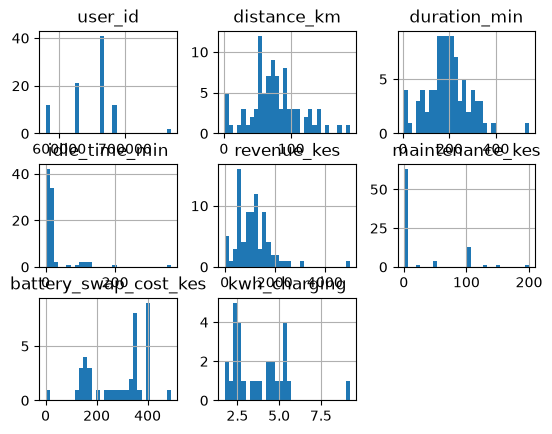

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
transition_ev_daily.hist(bins=30)
plt.title("Distribution of Daily Electric Motorcycle Data")

plt.xticks(rotation=45)
plt.show()

In [185]:
num_cols = transition_ev_daily.select_dtypes(include=['number']).columns
transition_ev_daily[num_cols] = transition_ev_daily[num_cols].fillna(
    transition_ev_daily[num_cols].median()
)

In [186]:
transition_ev_daily.isnull().sum()

user_id                  0
date                     0
distance_km              0
duration_min             0
idle_time_min            0
revenue_kes              0
maintenance_kes          0
battery_swap_cost_kes    0
kwh_charging             0
dtype: int64

In [197]:
transition_ev_daily.insert(0, 'category', 'electric_motorcycle')


In [187]:
transition_ev_trip = pd.read_sql("""SELECT * FROM transition_treatment_electric_motorcycle_trip_data""", conn)

In [188]:
transition_ev_trip.head()

,user_id,start_date,start_time,end_date,end_time,duration_min,distance_km,idle_time_min,start_lat,start_lon,end_lat,end_lon,avg_speed_kmh,avg_moving_speed_kmh,max_speed_kmh
0,579236,2023-12-10,11:06:51,2023-12-10,11:31:01,24.17,15.57,0.35,NaN,NaN,-1.257490,36.803090,38.65,39.22,59.0
1,579236,2023-12-10,12:11:25,2023-12-10,12:16:54,5.48,2.21,0.10,-1.257490,36.803090,-1.258252,36.818900,24.20,24.65,44.0
2,579236,2023-12-10,12:45:26,2023-12-10,12:50:34,5.13,2.52,0.47,-1.258252,36.818900,-1.264077,36.804105,29.47,32.45,53.0
3,579236,2023-12-10,12:53:10,2023-12-10,13:02:45,9.58,4.87,0.73,-1.264077,36.804105,-1.287638,36.777732,30.50,33.02,53.0
4,579236,2023-12-10,13:03:31,2023-12-10,13:05:09,1.63,0.37,0.33,-1.287638,36.777732,-1.288698,36.774793,13.62,17.08,21.0


In [189]:
transition_ev_trip.info()

<class 'pandas.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               3655 non-null   int64  
 1   start_date            3655 non-null   str    
 2   start_time            3655 non-null   str    
 3   end_date              3655 non-null   str    
 4   end_time              3655 non-null   str    
 5   duration_min          3655 non-null   float64
 6   distance_km           3655 non-null   float64
 7   idle_time_min         3655 non-null   float64
 8   start_lat             3567 non-null   float64
 9   start_lon             3567 non-null   float64
 10  end_lat               3567 non-null   float64
 11  end_lon               3567 non-null   float64
 12  avg_speed_kmh         3655 non-null   float64
 13  avg_moving_speed_kmh  3655 non-null   float64
 14  max_speed_kmh         3655 non-null   float64
dtypes: float64(10), int64(1), str(4)

In [190]:
transition_ev_trip.isnull().sum()

user_id                  0
start_date               0
start_time               0
end_date                 0
end_time                 0
duration_min             0
distance_km              0
idle_time_min            0
start_lat               88
start_lon               88
end_lat                 88
end_lon                 88
avg_speed_kmh            0
avg_moving_speed_kmh     0
max_speed_kmh            0
dtype: int64

<Figure size 1200x800 with 0 Axes>

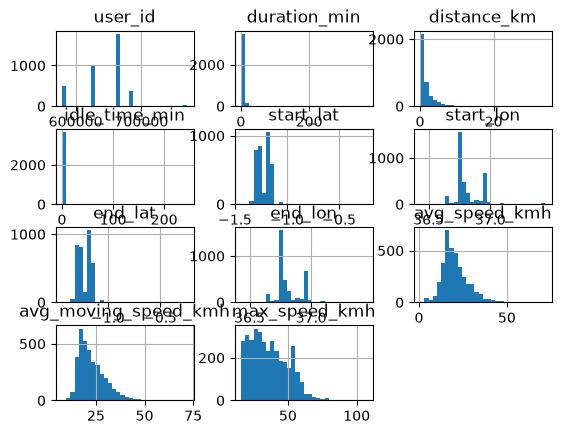

In [191]:
plt.figure(figsize=(12, 8))
transition_ev_trip.hist(bins=30)
plt.title("Distribution of Trip Electric Motorcycle Data")
plt.show()

In [192]:
transition_ev_trip.dropna(inplace=True)

In [193]:
transition_ev_trip.isnull().sum()

user_id                 0
start_date              0
start_time              0
end_date                0
end_time                0
duration_min            0
distance_km             0
idle_time_min           0
start_lat               0
start_lon               0
end_lat                 0
end_lon                 0
avg_speed_kmh           0
avg_moving_speed_kmh    0
max_speed_kmh           0
dtype: int64

In [198]:
transition_ev_trip.insert(0, 'category', 'electric_motorcycle')

In [194]:
transition_fuel_daily_columns = transition_fuel_daily.columns.tolist()

transition_fuel_trip_columns = transition_fuel_trip.columns.tolist()

transition_ev_daily_columns = transition_ev_daily.columns.tolist()

transition_ev_trip_columns = transition_ev_trip.columns.tolist()


print("Transition Fuel Daily Columns:", transition_fuel_daily_columns)
print("Transition Fuel Trip Columns:", transition_fuel_trip_columns)
print("Transition EV Daily Columns:", transition_ev_daily_columns)
print("Transition EV Trip Columns:", transition_ev_trip_columns)


Transition Fuel Daily Columns: ['user_id', 'date', 'distance_km', 'duration_min', 'idle_time_min', 'revenue_kes', 'maintenance_kes', 'fuel_cost_kes', 'fuel_unit_cost_kes_per_l', 'fuel_amount_l']
Transition Fuel Trip Columns: ['user_id', 'start_date', 'start_time', 'end_date', 'end_time', 'duration_min', 'distance_km', 'idle_time_min', 'start_lat', 'start_lon', 'end_lat', 'end_lon', 'avg_speed_kmh', 'avg_moving_speed_kmh', 'max_speed_kmh']
Transition EV Daily Columns: ['user_id', 'date', 'distance_km', 'duration_min', 'idle_time_min', 'revenue_kes', 'maintenance_kes', 'battery_swap_cost_kes', 'kwh_charging']
Transition EV Trip Columns: ['user_id', 'start_date', 'start_time', 'end_date', 'end_time', 'duration_min', 'distance_km', 'idle_time_min', 'start_lat', 'start_lon', 'end_lat', 'end_lon', 'avg_speed_kmh', 'avg_moving_speed_kmh', 'max_speed_kmh']


In [199]:
import pandas as pd

# Tag each dataset
transition_fuel_daily['vehicle_type'] = 'fuel'
transition_ev_daily['vehicle_type']   = 'ev'

transition_daily = pd.concat(
    [transition_fuel_daily, transition_ev_daily],
    axis=0,
    ignore_index=True,
    sort=False            # keeps all columns; missing ones become NaN
)

print(transition_daily.shape)
print(transition_daily['vehicle_type'].value_counts())

(1029, 14)
vehicle_type
fuel    941
ev       88
Name: count, dtype: int64


In [200]:
transition_fuel_trip['vehicle_type'] = 'fuel'
transition_ev_trip['vehicle_type']   = 'ev'

transition_trip = pd.concat(
    [transition_fuel_trip, transition_ev_trip],
    axis=0,
    ignore_index=True
)

print(transition_trip.shape)
print(transition_trip['vehicle_type'].value_counts())

(55280, 17)
vehicle_type
fuel    51799
ev       3481
Name: count, dtype: int64


In [201]:
import sqlite3

conn = sqlite3.connect("emobility_cleaned.db")   

transition_daily.to_sql(
    "transition_daily",   # table name
    conn,
    if_exists="append",   # 'append' | 'replace' | 'fail'
    index=False           # don't write pandas index as a column
)

transition_trip.to_sql(
    "transition_trip",
    conn,
    if_exists="append",
    index=False
)

conn.close()

In [202]:
conn = sqlite3.connect("emobility_cleaned.db")

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

                        name
0                battery_eol
1        country_qualitative
2              eac_countries
3             fiscal_tariffs
4     industrial_value_chain
5               market_fleet
6           policy_inventory
7              power_systems
8   eac_ev_charging_stations
9           transition_daily
10           transition_trip


In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("emobility copy.db")

In [2]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables 

,name
0,e_mobility_data_template_sow_4.1
1,kenya_ev_stations_(1)
2,e_mobility_data_template_sow_4_1
3,for_publication_africa_ev_readiness_impact_ind...
4,unep_eac_emobility_gantt_chart
5,unep_eac_emobility_weekly_live_chart
6,battery_eol
7,country_qualitative
8,eac_countries
9,financing


In [5]:
print(tables)

                                                 name
0                    e_mobility_data_template_sow_4.1
1                               kenya_ev_stations_(1)
2                    e_mobility_data_template_sow_4_1
3   for_publication_africa_ev_readiness_impact_ind...
4                      unep_eac_emobility_gantt_chart
5                unep_eac_emobility_weekly_live_chart
6                                         battery_eol
7                                 country_qualitative
8                                       eac_countries
9                                           financing
10                                     fiscal_tariffs
11                             industrial_value_chain
12                   kenya_ev_charging_infrastructure
13                                kenya_ev_stations_1
14                                       market_fleet
15                                      power_systems
16                      rwanda_ev_charging_stations_1
17                      tanz

In [6]:
xl = pd.read_sql(
    'SELECT * FROM "for_publication_africa_ev_readiness_impact_indicator_database_2025"',
    conn
)

In [8]:
xl

,ev_readiness_impact_index
0,HOW TO READ THIS SPREADSHEET
1,OVERVIEW
2,This spreadsheet contains the underlying data ...
3,1. MAIN SHEET
4,• Contains raw data for all indicators across ...
5,• Organized by major categories (Enabling Poli...
6,• Includes links to source data and methodolog...
7,• Shows latest available data for each indicator
8,2. SCORING TABS
9,Readiness Total Scores Tab:


In [1]:
import pandas as pd

file_path = "e-mobility cleaned datasets/EV_Readiness_Database.xlsx"

# Load ALL sheets at once into a dict
sheets = pd.read_excel(file_path, sheet_name=None)

# See what sheets exist
print(sheets.keys())

dict_keys(['How to Read', 'Overview', 'Scoring - Readiness', 'Scoring - Impact', 'Main Sheet', 'EV National Targets', 'EV Incentives', 'Additional Generation For 30% E', 'Grid Reliability', 'Current Rate of Motorization', 'EV Charging Infrastructure', 'Electricity Regulatory Index', ' Utility Cost Recovery', 'Relative Affordability', 'Access to Finance', 'Electricity Generated from Clea', 'CO2 from Transportation', 'Urban Air Quality', 'Fossil Fuel Import Dependence', 'Fossil Fuel Subsidy Burden', 'Utility Revenue Potential', 'Projected Rate of Motorization ', 'Readiness Total Scores', 'Impact Total Scores', 'Readiness Score Ranking', 'Impact Scores Ranking', 'Readiness and Impact Combined S'])


In [2]:
main = pd.read_excel(file_path, sheet_name="Main Sheet")
main.head()

,Country,Readiness - Preparedness to adopt EVs at a large scale\n,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Impact - Broader benefits of EV adoption\n,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,NaN,Enabling Policies,NaN,Grid Infrastrucutre,NaN,Market,NaN,Power Sector Maturity,NaN,EV Affordability,NaN,Climate,NaN,Public Health,Financial,NaN,NaN,Market Potential
1,NaN,National Target (2023),EV Incentives (2023),Additional Generation for 30% EVs (multiplicat...,Reliability (yearly average time without elect...,Current Rate of Motorization (2016),EV Charging Infrastructure (2024),ERI Score (2022),Utility Cost Recovery (Operating cost and debt...,Relative Affordability - Gas vs Charging (EV c...,Borrowed any money from a formal financial ins...,% Electricity generated from clean energy (2021),% CO2 Emissions from Transport (2020),Urban Air Quality (Custom AQI) (2019),Fossil Fuel Dependence (Ratio of transportatio...,"Fossil Fuel Subsidy Burden (% of GDP, gasoline...","Utility Revenue Potential ($, 30% EVs) (2021)",Projected rate of motorization (2050)
2,Algeria,1,0,1.166441,4.2,30.183765,6,0.644,Not Found,0.261002,0.04,0.011697,0.300828,193.230923,-323.222222,0.07436,438745467.3,167.402328
3,Angola,0,1,1.101579,12.8,30.183765,2,0.608,0.731342,0.085032,Not Found,0.713234,0.371962,320.401338,0.517609,0.036523,20026599.14,83.118222
4,Benin,0,1,9.997283,1243.2,20.107308,Not Found,0.465,0.929579,0.082833,0.11,0.03343,0.810718,292.90165,0.992663,0.005748,78092819.66,122.423516


In [3]:
# Use index 1 as the column names
main.columns = main.iloc[1]

# Remove rows 0 and 1
main = main.iloc[2:].reset_index(drop=True)

main.head()

1,NaN,National Target (2023),EV Incentives (2023),Additional Generation for 30% EVs (multiplication factor) (2016-2022),"Reliability (yearly average time without electricity, hours, various dates. SAIDI scores in yellow highlight. WBES scores w/o hightlight) (2010-2023)",Current Rate of Motorization (2016),EV Charging Infrastructure (2024),ERI Score (2022),"Utility Cost Recovery (Operating cost and debt service recovery, including subsidies) (2019)",Relative Affordability - Gas vs Charging (EV cost per 100 miles / ICE cost per 100 miles) (2022-2024),Borrowed any money from a formal financial institution or using a mobile money account (% age 15+) (2014-2022),% Electricity generated from clean energy (2021),% CO2 Emissions from Transport (2020),Urban Air Quality (Custom AQI) (2019),Fossil Fuel Dependence (Ratio of transportation fuel consumption to net imports by country) (2021),"Fossil Fuel Subsidy Burden (% of GDP, gasoline & diesel, explicit subsidies) (2023)","Utility Revenue Potential ($, 30% EVs) (2021)",Projected rate of motorization (2050)
0,Algeria,1,0,1.166441,4.2,30.183765,6,0.644,Not Found,0.261002,0.04,0.011697,0.300828,193.230923,-323.222222,0.07436,438745467.3,167.402328
1,Angola,0,1,1.101579,12.8,30.183765,2,0.608,0.731342,0.085032,Not Found,0.713234,0.371962,320.401338,0.517609,0.036523,20026599.14,83.118222
2,Benin,0,1,9.997283,1243.2,20.107308,Not Found,0.465,0.929579,0.082833,0.11,0.03343,0.810718,292.90165,0.992663,0.005748,78092819.66,122.423516
3,Botswana,0,0,1.390465,152.64,198.199213,3,0.527,0.792663,0.268729,0.11,0.002749,0.369206,202.304685,0.824639,0,95438692.93,399.461294
4,Burkina Faso,0,0,1.555002,388.08,16.818502,1,0.495,1.041419,0.826633,0.09,0.132993,0.54784,251.658675,0.860847,0.005313,438885972.9,67.572258


In [4]:
main.columns

Index([                                                                                                                                                    nan,
                                                                                                                                      'National Target (2023)',
                                                                                                                                        'EV Incentives (2023)',
                                                                                       'Additional Generation for 30% EVs (multiplication factor) (2016-2022)',
       'Reliability (yearly average time without electricity, hours, various dates. SAIDI scores in yellow highlight. WBES scores w/o hightlight) (2010-2023)',
                                                                                                                         'Current Rate of Motorization (2016)',
                                        

In [5]:
main.info()

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 18 columns):
 #   Column                                                                                                                                                 Non-Null Count  Dtype 
---  ------                                                                                                                                                 --------------  ----- 
 0   nan                                                                                                                                                    54 non-null     str   
 1   National Target (2023)                                                                                                                                 54 non-null     str   
 2   EV Incentives (2023)                                                                                                                                   54 non-null     str   
 3   Addition

In [7]:
main = main.rename(columns={main.columns[0]: "Country"})

In [8]:
main.head()

1,Country,National Target (2023),EV Incentives (2023),Additional Generation for 30% EVs (multiplication factor) (2016-2022),"Reliability (yearly average time without electricity, hours, various dates. SAIDI scores in yellow highlight. WBES scores w/o hightlight) (2010-2023)",Current Rate of Motorization (2016),EV Charging Infrastructure (2024),ERI Score (2022),"Utility Cost Recovery (Operating cost and debt service recovery, including subsidies) (2019)",Relative Affordability - Gas vs Charging (EV cost per 100 miles / ICE cost per 100 miles) (2022-2024),Borrowed any money from a formal financial institution or using a mobile money account (% age 15+) (2014-2022),% Electricity generated from clean energy (2021),% CO2 Emissions from Transport (2020),Urban Air Quality (Custom AQI) (2019),Fossil Fuel Dependence (Ratio of transportation fuel consumption to net imports by country) (2021),"Fossil Fuel Subsidy Burden (% of GDP, gasoline & diesel, explicit subsidies) (2023)","Utility Revenue Potential ($, 30% EVs) (2021)",Projected rate of motorization (2050)
0,Algeria,1,0,1.166441,4.2,30.183765,6,0.644,Not Found,0.261002,0.04,0.011697,0.300828,193.230923,-323.222222,0.07436,438745467.3,167.402328
1,Angola,0,1,1.101579,12.8,30.183765,2,0.608,0.731342,0.085032,Not Found,0.713234,0.371962,320.401338,0.517609,0.036523,20026599.14,83.118222
2,Benin,0,1,9.997283,1243.2,20.107308,Not Found,0.465,0.929579,0.082833,0.11,0.03343,0.810718,292.90165,0.992663,0.005748,78092819.66,122.423516
3,Botswana,0,0,1.390465,152.64,198.199213,3,0.527,0.792663,0.268729,0.11,0.002749,0.369206,202.304685,0.824639,0,95438692.93,399.461294
4,Burkina Faso,0,0,1.555002,388.08,16.818502,1,0.495,1.041419,0.826633,0.09,0.132993,0.54784,251.658675,0.860847,0.005313,438885972.9,67.572258


In [9]:
import pandas as pd

# EAC countries to keep
eac_countries = [
    "Kenya",
    "Uganda",
    "Tanzania",
    "Rwanda",
    "Burundi",
    "DR Congo",
    "South Sudan",
    "Somalia"
]

# Filter the dataset
eac_df = main[main["Country"].isin(eac_countries)].copy()

# Save as CSV
eac_df.to_csv("eac_ev_readiness_main.csv", index=False)

# Check the result
print(f"Rows saved: {len(eac_df)}")
print(eac_df["Country"].tolist())

Rows saved: 8
['Burundi', 'DR Congo', 'Kenya', 'Rwanda', 'Somalia', 'South Sudan', 'Tanzania', 'Uganda']


In [10]:
eac_df.head()

1,Country,National Target (2023),EV Incentives (2023),Additional Generation for 30% EVs (multiplication factor) (2016-2022),"Reliability (yearly average time without electricity, hours, various dates. SAIDI scores in yellow highlight. WBES scores w/o hightlight) (2010-2023)",Current Rate of Motorization (2016),EV Charging Infrastructure (2024),ERI Score (2022),"Utility Cost Recovery (Operating cost and debt service recovery, including subsidies) (2019)",Relative Affordability - Gas vs Charging (EV cost per 100 miles / ICE cost per 100 miles) (2022-2024),Borrowed any money from a formal financial institution or using a mobile money account (% age 15+) (2014-2022),% Electricity generated from clean energy (2021),% CO2 Emissions from Transport (2020),Urban Air Quality (Custom AQI) (2019),Fossil Fuel Dependence (Ratio of transportation fuel consumption to net imports by country) (2021),"Fossil Fuel Subsidy Burden (% of GDP, gasoline & diesel, explicit subsidies) (2023)","Utility Revenue Potential ($, 30% EVs) (2021)",Projected rate of motorization (2050)
5,Burundi,0,0,1.152476,956.16,4.000614,Not Found,0.284,1.135605,0.289235,Not Found,0.653054,0.799859,281.190257,0.789474,0,8624416.71,22.903843
14,DR Congo,0,1,1.150582,826.56,0.726836,1,0.527,0.764702,0.166545,0.05,0.301487,0.996308,293.776681,1,0,51879930.06,37.654797
25,Kenya,1,1,1.252014,264.48,53.906771,18,0.695,0.893357,0.272812,0.4,0.919853,0.660085,150.175001,0.854979,0,426419384.6,173.878629
39,Rwanda,1,1,1.078061,97.2,15.216288,4,0.605,0.891225,0.151835,Not Found,0.594395,0.47128,223.740653,0.740157,0,5403906.673,126.40596
44,Somalia,0,0,1.069391,Not Found,4.159913,11,Not Found,Not Found,0.197831,Not Found,0.086986,0.215324,141.510067,0.341176,0,2235959.888,38.699564


In [12]:
ev_inc = pd.read_excel(file_path, sheet_name="EV Incentives")
ev_inc.head()

,Country,Level,Policy type,Key policy measures and targets,Year announced,Category,Source,Source.1
0,Angola,National,Legislation,50% reduction of both import duty and vehicle ...,2022.0,Multiple,Government of Angola,IEA
1,Angola,National,Legislation,50% reduction in import customs duty and motor...,2022.0,NaN,Source,Climatescope
2,Benin,National,Legislation,Exempt 100% EVs from VAT and custom duties,2023.0,NaN,Source,NaN
3,Cabo Verde,National,Legislation,Exemption from VAT and excise duties on the im...,2022.0,EVSE,ICCT,NaN
4,DR Congo,Multi-national,Legislation (agreement),Afreximbank and ECA sign Framework Agreement t...,2023.0,NaN,Source,NaN


In [14]:
ev_inc

,Country,Level,Policy type,Key policy measures and targets,Year announced,Category,Source,Source.1
0,Angola,National,Legislation,50% reduction of both import duty and vehicle ...,2022.0,Multiple,Government of Angola,IEA
1,Angola,National,Legislation,50% reduction in import customs duty and motor...,2022.0,NaN,Source,Climatescope
2,Benin,National,Legislation,Exempt 100% EVs from VAT and custom duties,2023.0,NaN,Source,NaN
3,Cabo Verde,National,Legislation,Exemption from VAT and excise duties on the im...,2022.0,EVSE,ICCT,NaN
4,DR Congo,Multi-national,Legislation (agreement),Afreximbank and ECA sign Framework Agreement t...,2023.0,NaN,Source,NaN
5,Egypt,National,Legislation,Ministerial Resolution 255/2018 exempts EVs fr...,2018.0,NaN,Source,Climatescope
6,Egypt,National,Legislation (announced),"Financial support up to EGP 50,000 for buyers ...",2021.0,NaN,Source,Climatescope
7,Ethiopia,National,Legislation,EVs are not subject to import duties if locall...,2022.0,Multiple,Government of Ethiopia,IEA
8,Ethiopia,National,Legislation,"Exempts EVs from VAT, excise tax, and surtaxes...",2022.0,NaN,Source,Climatescope
9,Ethiopia,National,Legislation (announced),An immediate ban on all ICE vehicle imports,2024.0,NaN,Source,NaN


In [13]:
# EAC countries to keep
eac_countries = [
    "Kenya",
    "Uganda",
    "Tanzania",
    "Rwanda",
    "Burundi",
    "DR Congo",
    "South Sudan",
    "Somalia"
]

# Filter the dataset
eac_df_ev = ev_inc[ev_inc["Country"].isin(eac_countries)].copy()

# Save as CSV
eac_df_ev.to_csv("eac_ev_incentives.csv", index=False)

# Check the result
print(f"Rows saved: {len(eac_df_ev)}")
print(eac_df_ev["Country"].tolist())

Rows saved: 8
['DR Congo', 'Kenya', 'Kenya', 'Rwanda', 'Rwanda', 'Rwanda', 'Rwanda', 'Uganda']


In [16]:
eac_df_ev

,Country,Level,Policy type,Key policy measures and targets,Year announced,Category,Source,Source.1
4,DR Congo,Multi-national,Legislation (agreement),Afreximbank and ECA sign Framework Agreement t...,2023.0,NaN,Source,NaN
12,Kenya,National,Legislation,Finance Bill of 2019 proposed reduction on the...,2019.0,NaN,Source,NaN
13,Kenya,National,Legislation,Kenya released draft of National E-mobility po...,2024.0,NaN,Source,Policy
20,Rwanda,National,Legislation,"VAT, withholding tax, and import duty exemptio...",2021.0,Multiple,Government of Rwanda,IEA
21,Rwanda,National,Legislation,Tariffs at charging stations are capped at ind...,2021.0,EVSE,Government of Rwanda,IEA
22,Rwanda,National,Legislation,"Introduction of a carbon tax, establishment of...",2021.0,Multiple,Government of Rwanda,IEA
23,Rwanda,National,Legislation,Exempts electric vehicles from import duties a...,2023.0,NaN,"Source, Source",Climatescope
29,Uganda,National,Legislation,Exempt hybrid and electric vehicles from impor...,2023.0,NaN,Source,NaN


In [17]:
add_gen = pd.read_excel(file_path, sheet_name="Additional Generation For 30% E")

add_gen

,Country,Percent added generation required 100% (GWh),Percent added generation required (GWh) (30%),Multiplication factor for 30% EVs,"Score: \nLow readiness (25% +), Medium readiness (25%-10%), High readiness (10%-0)",Score,"Updated data from May 27, 2024",Source
0,Algeria,55.480274,0.166441,1.166441,Medium Expansion (medium readiness),0.666667,16.644082,AFREC
1,Angola,33.859712,0.101579,1.101579,Medium Expansion (medium readiness),0.666667,10.157914,NaN
2,Benin,2999.094415,8.997283,9.997283,Large expansion (low readiness),0.333333,899.728325,NaN
3,Botswana,130.154984,0.390465,1.390465,Large expansion (low readiness),0.333333,39.046495,NaN
4,Burkina Faso,185.000526,0.555002,1.555002,Large expansion (low readiness),0.333333,55.500158,NaN
...,...,...,...,...,...,...,...,...
73,NaN,NaN,Scoring Categories: \n• Large expansion (>25%)...,NaN,NaN,NaN,NaN,NaN
74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75,NaN,NaN,Key Statistics: \n• Minimum value: Cameroon (0...,NaN,NaN,NaN,NaN,NaN
76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# EAC countries to keep
eac_countries = [
    "Kenya",
    "Uganda",
    "Tanzania",
    "Rwanda",
    "Burundi",
    "DR Congo",
    "South Sudan",
    "Somalia"
]

# Filter the dataset
eac_df_gen = add_gen[add_gen["Country"].isin(eac_countries)].copy()

# Save as CSV
eac_df_gen.to_csv("eac_ev_generation.csv", index=False)

# Check the result
print(f"Rows saved: {len(eac_df_gen)}")
print(eac_df_gen["Country"].tolist())

Rows saved: 8
['Burundi', 'DR Congo', 'Kenya', 'Rwanda', 'Somalia', 'South Sudan', 'Tanzania', 'Uganda']


In [19]:
eac_df_gen.head()

,Country,Percent added generation required 100% (GWh),Percent added generation required (GWh) (30%),Multiplication factor for 30% EVs,"Score: \nLow readiness (25% +), Medium readiness (25%-10%), High readiness (10%-0)",Score,"Updated data from May 27, 2024",Source
5,Burundi,50.825364,0.152476,1.152476,Medium Expansion (medium readiness),0.666667,15.247609,NaN
14,DR Congo,50.193837,0.150582,1.150582,Medium Expansion (medium readiness),0.666667,15.058151,NaN
25,Kenya,84.004542,0.252014,1.252014,Large expansion (low readiness),0.333333,25.201363,NaN
39,Rwanda,26.020358,0.078061,1.078061,Modest Expansion (high readiness),1.000000,7.806107,NaN
44,Somalia,23.130406,0.069391,1.069391,Modest Expansion (high readiness),1.000000,6.939122,NaN


In [20]:
grid = pd.read_excel(file_path, sheet_name="Grid Reliability")
grid

,Country,Percent of firms \nexperiencing electrical outages,Number of electrical \noutages in a typical month,"If there were outages, \naverage duration of \na typical electrical outage (hours)",Average time without \nelectricity (hours) in a typical month,Yearly average \ntime without electricity (hours),"Scoring:\nWBES: Low: 250+, Medium: 50-249, High:<50\nSAIDI: Low: 20+, Medium: 5-20, High: 0-5",Score - WBES only,WBES dates,SAIDI dates,"WBES & SAIDI\nCriteria:\nUse SAIDI data if Enterprise data is missing, \nEnterprise data is from 2010 or before, and a more recent SAIDI value is available, otherwise Enterprise data is used",Score\nWBES & SAIDI,Source(s),DIVIDER,WB SAIDI (2014-2019),WB SAIDI (added June 11th),WB SAIDI source
0,Algeria,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found,2019,4.2,1,World Bank,WB SAIDI\n-->,4.2,4.2,NaN
1,Angola,87.7,4.7,13.5,63.45,761.4,Low reliability,0.333333,2010,2019,12.8,0.666667,World Bank,NaN,12.8,12.8,NaN
2,Benin,95.6,28,3.7,103.6,1243.2,Low reliability,0.333333,2016,Not Found,1243.2,0.333333,NaN,NaN,Not Found,Not Found,NaN
3,Botswana,64.2,2.4,5.3,12.72,152.64,Medium reliability,0.666667,2023,Not Found,152.64,0.666667,NaN,NaN,Not Found,Not Found,NaN
4,Burkina Faso,91.9,9.8,3.3,32.34,388.08,Low reliability,0.333333,2009,Not Found,388.08,0.333333,NaN,NaN,Not Found,Not Found,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
grid.head(60)

,Country,Percent of firms \nexperiencing electrical outages,Number of electrical \noutages in a typical month,"If there were outages, \naverage duration of \na typical electrical outage (hours)",Average time without \nelectricity (hours) in a typical month,Yearly average \ntime without electricity (hours),"Scoring:\nWBES: Low: 250+, Medium: 50-249, High:<50\nSAIDI: Low: 20+, Medium: 5-20, High: 0-5",Score - WBES only,WBES dates,SAIDI dates,"WBES & SAIDI\nCriteria:\nUse SAIDI data if Enterprise data is missing, \nEnterprise data is from 2010 or before, and a more recent SAIDI value is available, otherwise Enterprise data is used",Score\nWBES & SAIDI,Source(s),DIVIDER,WB SAIDI (2014-2019),WB SAIDI (added June 11th),WB SAIDI source
0,Algeria,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found,2019,4.2,1,World Bank,WB SAIDI\n-->,4.2,4.2,NaN
1,Angola,87.7,4.7,13.5,63.45,761.4,Low reliability,0.333333,2010,2019,12.8,0.666667,World Bank,NaN,12.8,12.8,NaN
2,Benin,95.6,28,3.7,103.6,1243.2,Low reliability,0.333333,2016,Not Found,1243.2,0.333333,NaN,NaN,Not Found,Not Found,NaN
3,Botswana,64.2,2.4,5.3,12.72,152.64,Medium reliability,0.666667,2023,Not Found,152.64,0.666667,NaN,NaN,Not Found,Not Found,NaN
4,Burkina Faso,91.9,9.8,3.3,32.34,388.08,Low reliability,0.333333,2009,Not Found,388.08,0.333333,NaN,NaN,Not Found,Not Found,NaN
5,Burundi,85.1,16.6,4.8,79.68,956.16,Low reliability,0.333333,2014,2014,956.16,0.333333,NaN,NaN,660,660,NaN
6,Cabo Verde,74,3.2,9.2,29.44,353.28,Low reliability,0.333333,2009,2019,18.3,0.666667,NaN,NaN,18.3,18.3,NaN
7,Cameroon,92.5,7.6,8.7,66.12,793.44,Low reliability,0.333333,2016,Not Found,793.44,0.333333,NaN,NaN,Not Found,Not Found,NaN
8,Central African Republic,89.3,28.3,7.1,200.93,2411.16,Low reliability,0.333333,2023,Not Found,2411.16,0.333333,NaN,NaN,Not Found,Not Found,NaN
9,Chad,96.2,15.9,15.1,240.09,2881.08,Low reliability,0.333333,2023,Not Found,2881.08,0.333333,NaN,NaN,Not Found,Not Found,NaN


In [22]:
# EAC countries to keep
eac_countries = [
    "Kenya",
    "Uganda",
    "Tanzania",
    "Rwanda",
    "Burundi",
    "DR Congo",
    "South Sudan",
    "Somalia"
]

# Filter the dataset
eac_df_grid = grid[grid["Country"].isin(eac_countries)].copy()

# Save as CSV
eac_df_grid.to_csv("eac_ev_readiness_grid.csv", index=False)

# Check the result
print(f"Rows saved: {len(eac_df)}")
print(eac_df["Country"].tolist())

Rows saved: 8
['Burundi', 'DR Congo', 'Kenya', 'Rwanda', 'Somalia', 'South Sudan', 'Tanzania', 'Uganda']


In [23]:
eac_df_grid.head()

,Country,Percent of firms \nexperiencing electrical outages,Number of electrical \noutages in a typical month,"If there were outages, \naverage duration of \na typical electrical outage (hours)",Average time without \nelectricity (hours) in a typical month,Yearly average \ntime without electricity (hours),"Scoring:\nWBES: Low: 250+, Medium: 50-249, High:<50\nSAIDI: Low: 20+, Medium: 5-20, High: 0-5",Score - WBES only,WBES dates,SAIDI dates,"WBES & SAIDI\nCriteria:\nUse SAIDI data if Enterprise data is missing, \nEnterprise data is from 2010 or before, and a more recent SAIDI value is available, otherwise Enterprise data is used",Score\nWBES & SAIDI,Source(s),DIVIDER,WB SAIDI (2014-2019),WB SAIDI (added June 11th),WB SAIDI source
5,Burundi,85.1,16.6,4.8,79.68,956.16,Low reliability,0.333333,2014,2014,956.16,0.333333,NaN,NaN,660,660,NaN
14,DR Congo,89.3,12.3,5.6,68.88,826.56,Low reliability,0.333333,2013,Not Found,826.56,0.333333,NaN,NaN,Not Found,Not Found,NaN
25,Kenya,82.8,3.8,5.8,22.04,264.48,Low reliability,0.333333,2018,2019,264.48,0.333333,NaN,NaN,12,12,NaN
39,Rwanda,60.6,1.8,4.5,8.1,97.2,Medium reliability,0.666667,2023,2019,97.2,0.666667,NaN,NaN,2.8,2.8,NaN
44,Somalia,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found,Not Found,NaN,NaN,Not Found,Not Found,NaN


In [24]:
mot = pd.read_excel(file_path, sheet_name="Current Rate of Motorization")
mot.head()

,Country,Current rate of motorization (2016) (number of vehicles per 1000 people),"Scoring: \nLow: <100, Medium: 100-200, \nHigh: >200",Score,Source(s)
0,Algeria,140.624368,Medium motorization rate,0.666667,"IRF, OICA, WHO, WorldData.info, \nMalawi Minis..."
1,Angola,30.183765,Low motorization rate,0.333333,NaN
2,Benin,20.107308,Low motorization rate,0.333333,NaN
3,Botswana,198.199213,Medium motorization rate,0.666667,NaN
4,Burkina Faso,16.818502,Low motorization rate,0.333333,NaN


In [25]:
# EAC countries to keep
eac_countries = [
    "Kenya",
    "Uganda",
    "Tanzania",
    "Rwanda",
    "Burundi",
    "DR Congo",
    "South Sudan",
    "Somalia"
]

# Filter the dataset
eac_df_mot = mot[mot["Country"].isin(eac_countries)].copy()

# Save as CSV
eac_df_mot.to_csv("eac_ev_readiness_motorization_rate.csv", index=False)

# Check the result
print(f"Rows saved: {len(eac_df_mot)}")
print(eac_df_mot["Country"].tolist())

Rows saved: 8
['Burundi', 'DR Congo', 'Kenya', 'Rwanda', 'Somalia', 'South Sudan', 'Tanzania', 'Uganda']


In [26]:
eac_df_mot

,Country,Current rate of motorization (2016) (number of vehicles per 1000 people),"Scoring: \nLow: <100, Medium: 100-200, \nHigh: >200",Score,Source(s)
5,Burundi,4.000614,Low motorization rate,0.333333,NaN
14,DR Congo,0.726836,Low motorization rate,0.333333,NaN
25,Kenya,53.906771,Low motorization rate,0.333333,NaN
39,Rwanda,15.216288,Low motorization rate,0.333333,NaN
44,Somalia,4.159913,Low motorization rate,0.333333,NaN
46,South Sudan,6.293723,Low motorization rate,0.333333,NaN
48,Tanzania,37.998686,Low motorization rate,0.333333,NaN
51,Uganda,24.502521,Low motorization rate,0.333333,NaN


In [27]:
elec_index = pd.read_excel(file_path, sheet_name="Electricity Regulatory Index")
elec_index.head()

,Country,ERI 2021,ERI 2022,"Scoring: \nLow: 0-0.499, Medium: 0.500-0.799, High: 0.800+",Score,Source(s)
0,Algeria,0.6,0.644,Medium,0.666667,AEP
1,Angola,0.59,0.608,Medium,0.666667,NaN
2,Benin,0.53,0.465,Low,0.333333,NaN
3,Botswana,0.45,0.527,Medium,0.666667,NaN
4,Burkina Faso,0.48,0.495,Low,0.333333,NaN


In [28]:
# EAC countries to keep
eac_countries = [
    "Kenya",
    "Uganda",
    "Tanzania",
    "Rwanda",
    "Burundi",
    "DR Congo",
    "South Sudan",
    "Somalia"
]

# Filter the dataset
eac_df_elec = elec_index[elec_index["Country"].isin(eac_countries)].copy()

# Save as CSV
eac_df_elec.to_csv("eac_ev_readiness_electricity_regulatory_index.csv", index=False)

# Check the result
print(f"Rows saved: {len(eac_df_elec)}")
print(eac_df_elec["Country"].tolist())

Rows saved: 8
['Burundi', 'DR Congo', 'Kenya', 'Rwanda', 'Somalia', 'South Sudan', 'Tanzania', 'Uganda']


In [29]:
eac_df_elec.head()

,Country,ERI 2021,ERI 2022,"Scoring: \nLow: 0-0.499, Medium: 0.500-0.799, High: 0.800+",Score,Source(s)
5,Burundi,0.29,0.284,Low,0.333333,NaN
14,DR Congo,0.42,0.527,Medium,0.666667,NaN
25,Kenya,0.69,0.695,Medium,0.666667,NaN
39,Rwanda,0.6,0.605,Medium,0.666667,NaN
44,Somalia,Not Found,Not Found,Not Found,Not Found,NaN


In [30]:
rel_afford = pd.read_excel(file_path, sheet_name='Relative Affordability')
rel_afford.head()

,Country,Commercial electricity price ($/kWh) - 2022,Gasoline pump price ($/L) - 2022,ICE fuel cost,EV fuel cost,EV Charging Relative Affordability,"Scoring: \nEV pricier (>1) Comparable (0.75-1) , EV cheaper (<0.75)",Score,Source(s)
0,Algeria,0.034,0.336,4.102896,1.070865,0.261002,EV cheaper,1.000000,"Climatescope, BloombergNEF, GlobalPetrolPrices..."
1,Angola,0.012,0.364,4.444804,0.377952,0.085032,EV cheaper,1.000000,NaN
2,Benin,0.036,1.121,13.688531,1.133857,0.082833,EV cheaper,1.000000,NaN
3,Botswana,0.112,1.075,13.126825,3.527554,0.268729,EV cheaper,1.000000,NaN
4,Burkina Faso,0.449,1.401,17.107611,14.141713,0.826633,Comparable,0.666667,NaN


In [31]:
# EAC countries to keep
eac_countries = [
    "Kenya",
    "Uganda",
    "Tanzania",
    "Rwanda",
    "Burundi",
    "DR Congo",
    "South Sudan",
    "Somalia"
]

# Filter the dataset
eac_df_rel_afford = rel_afford[rel_afford["Country"].isin(eac_countries)].copy()

# Save as CSV
eac_df_rel_afford.to_csv("eac_ev_readiness_relative_affordability.csv", index=False)

# Check the result
print(f"Rows saved: {len(eac_df_rel_afford)}")
print(eac_df_rel_afford["Country"].tolist())

Rows saved: 8
['Burundi', 'DR Congo', 'Kenya', 'Rwanda', 'Somalia', 'South Sudan', 'Tanzania', 'Uganda']


In [33]:
eac_df_rel_afford

,Country,Commercial electricity price ($/kWh) - 2022,Gasoline pump price ($/L) - 2022,ICE fuel cost,EV fuel cost,EV Charging Relative Affordability,"Scoring: \nEV pricier (>1) Comparable (0.75-1) , EV cheaper (<0.75)",Score,Source(s)
5,Burundi,0.158,1.409,17.205299,4.976371,0.289235,EV cheaper,1.000000,NaN
14,DR Congo,0.078,1.208,14.750888,2.45669,0.166545,EV cheaper,1.000000,NaN
25,Kenya,0.143,1.352,16.509272,4.503931,0.272812,EV cheaper,1.000000,NaN
39,Rwanda,0.081,1.376,16.802336,2.551178,0.151835,EV cheaper,1.000000,NaN
44,Somalia,0.079,1.03,12.577330,2.488186,0.197831,EV cheaper,1.000000,NaN
46,South Sudan,0.420,1.4,17.095400,13.228328,0.773795,Comparable,0.666667,NaN
48,Tanzania,0.095,1.28,15.630080,2.992122,0.191434,EV cheaper,1.000000,NaN
51,Uganda,0.130,1.274,15.556814,4.094483,0.263195,EV cheaper,1.000000,NaN


In [34]:
finance = pd.read_excel(file_path, sheet_name='Access to Finance')
finance.head()

,Country,Year,Access to Finance\n(Borrowed any money \nfrom a formal financial institution \nor using a mobile money account (% age 15+)),"Scoring:\nLow:<20%, Medium: 20-40%, High: >40%",Score,Source
0,Algeria,2021.0,0.04,Low,0.333333,"World Bank Global Findex, 2021"
1,Angola,NaN,Not Found,Not Found,Not Found,NaN
2,Benin,2021.0,0.11,Low,0.333333,NaN
3,Botswana,2022.0,0.11,Low,0.333333,NaN
4,Burkina Faso,2021.0,0.09,Low,0.333333,NaN


In [35]:
# EAC countries to keep
eac_countries = [
    "Kenya",
    "Uganda",
    "Tanzania",
    "Rwanda",
    "Burundi",
    "DR Congo",
    "South Sudan",
    "Somalia"
]

# Filter the dataset
eac_df_finance = finance[finance["Country"].isin(eac_countries)].copy()

# Save as CSV
eac_df_finance.to_csv("eac_ev_readiness_finance.csv", index=False)

# Check the result
print(f"Rows saved: {len(eac_df_finance)}")
print(eac_df_finance["Country"].tolist())

Rows saved: 8
['Burundi', 'DR Congo', 'Kenya', 'Rwanda', 'Somalia', 'South Sudan', 'Tanzania', 'Uganda']


In [36]:
eac_df_finance

,Country,Year,Access to Finance\n(Borrowed any money \nfrom a formal financial institution \nor using a mobile money account (% age 15+)),"Scoring:\nLow:<20%, Medium: 20-40%, High: >40%",Score,Source
5,Burundi,2014.0,Not Found,Not Found,Not Found,NaN
14,DR Congo,2022.0,0.05,Low,0.333333,NaN
25,Kenya,2021.0,0.4,High,1,NaN
39,Rwanda,2017.0,Not Found,Not Found,Not Found,NaN
44,Somalia,2014.0,Not Found,Not Found,Not Found,NaN
46,South Sudan,2021.0,0.03,Low,0.333333,NaN
48,Tanzania,2021.0,0.13,Low,0.333333,NaN
51,Uganda,2021.0,0.29,Medium,0.666667,NaN


In [37]:
elec_gen =pd.read_excel(file_path, sheet_name='Electricity Generated from Clea')
elec_gen.head()

,Country,Electricity net generation (billion kWh),Nuclear,Renewables,Fossil Fuels,% Clean,% Dirty,"Scoring: \nLow: <33%, Medium:33%-66%, High: >66%",Score,Source(s)
0,Algeria,77.530727,0,0.906860,76.623867,0.011697,0.988303,Low,0.333333,U.S. Energy Information Administration
1,Angola,16.429392,0,11.718000,4.711392,0.713234,0.286766,High,1.000000,NaN
2,Benin,0.241097,0,0.008060,0.233037,0.033430,0.966570,Low,0.333333,NaN
3,Botswana,2.182348,0,0.006000,2.176348,0.002749,0.997251,Low,0.333333,NaN
4,Burkina Faso,1.761210,0,0.234228,1.526982,0.132993,0.867007,Low,0.333333,NaN


In [38]:
# EAC countries to keep
eac_countries = [
    "Kenya",
    "Uganda",
    "Tanzania",
    "Rwanda",
    "Burundi",
    "DR Congo",
    "South Sudan",
    "Somalia"
]

# Filter the dataset
eac_df_elec_gen = elec_gen[elec_gen["Country"].isin(eac_countries)].copy()

# Save as CSV
eac_df_elec_gen.to_csv("eac_ev_readiness_electricity_generated_to_clean_energy.csv", index=False)

# Check the result
print(f"Rows saved: {len(eac_df_elec_gen)}")
print(eac_df_elec_gen["Country"].tolist())

Rows saved: 8
['Burundi', 'DR Congo', 'Kenya', 'Rwanda', 'Somalia', 'South Sudan', 'Tanzania', 'Uganda']


In [39]:
eac_df_elec_gen.head()

,Country,Electricity net generation (billion kWh),Nuclear,Renewables,Fossil Fuels,% Clean,% Dirty,"Scoring: \nLow: <33%, Medium:33%-66%, High: >66%",Score,Source(s)
5,Burundi,0.357992,0,0.233788,0.124204,0.653054,0.346946,Medium,0.666667,NaN
14,DR Congo,11.039641,0,11.034000,0.005641,0.999489,0.000511,High,1.000000,NaN
25,Kenya,11.832514,0,10.884171,0.948343,0.919853,0.080147,High,1.000000,NaN
39,Rwanda,0.854651,0,0.508000,0.346651,0.594395,0.405605,Medium,0.666667,NaN
44,Somalia,0.407880,0,0.035480,0.3724,0.086986,0.913014,Low,0.333333,NaN


In [40]:
co = pd.read_excel(file_path, sheet_name='CO2 from Transportation')
co.head()

,Country,Year,CO2 from fuel combustion,Transport CO2,% of CO2 from Transport,"Scoring: \nLow: 0-33%, Medium: 33%-66.67%, High: 66.67%-100%",Score,Source(s)
0,Algeria,2020.0,134515.1,40465.9,0.300828,Low,0.333333,"Greenhouse Gas Emissions from Energy, IEA"
1,Angola,2020.0,15141.6,5632.1,0.371962,Medium,0.666667,"World Energy Balances, IEA"
2,Benin,2020.0,7611.4,6170.7,0.810718,High,1.000000,NaN
3,Botswana,2020.0,5760.2,2126.7,0.369206,Medium,0.666667,NaN
4,Burkina Faso,2020.0,4608.1,2524.5,0.54784,Medium,0.666667,NaN


In [41]:
# EAC countries to keep
eac_countries = [
    "Kenya",
    "Uganda",
    "Tanzania",
    "Rwanda",
    "Burundi",
    "DR Congo",
    "South Sudan",
    "Somalia"
]

# Filter the dataset
eac_df_co = co[co["Country"].isin(eac_countries)].copy()

# Save as CSV
eac_df_co.to_csv("eac_ev_readiness_co2_transportation.csv", index=False)

# Check the result
print(f"Rows saved: {len(eac_df_co)}")
print(eac_df_co["Country"].tolist())

Rows saved: 8
['Burundi', 'DR Congo', 'Kenya', 'Rwanda', 'Somalia', 'South Sudan', 'Tanzania', 'Uganda']


In [42]:
eac_df_co.head()

,Country,Year,CO2 from fuel combustion,Transport CO2,% of CO2 from Transport,"Scoring: \nLow: 0-33%, Medium: 33%-66.67%, High: 66.67%-100%",Score,Source(s)
5,Burundi,2020.0,710.5,568.3,0.799859,High,1.000000,NaN
14,DR Congo,2020.0,2329.5,2320.9,0.996308,High,1.000000,NaN
25,Kenya,2020.0,15754.8,10399.5,0.660085,Medium,0.666667,NaN
39,Rwanda,2020.0,1232.6,580.9,0.47128,Medium,0.666667,NaN
44,Somalia,2020.0,660.4,142.2,0.215324,Low,0.333333,NaN


In [43]:
fossil = pd.read_excel(file_path, sheet_name='Fossil Fuel Import Dependence')
fossil.head()

,Country,Gasoline_Diesel imports,Gasoline_Diesel Exports,Net imports,Final gasoline_diesel consumption transport,Net imports percent,Consumption/Net Imports,Exports/Imports,"Scoring:\nLow: <33.33%, Medium: 33.33-66.67%, High: >66.67%",Score(s),Source(s)
0,Algeria,677.0,713,-36.0,11636,-0.3,-323.222222,1.053176,Low impact,0.333333,AFREC
1,Angola,2033.0,159,1874.0,970,193.2,0.517609,0.07821,Medium impact,0.666667,NaN
2,Benin,1363.0,0,1363.0,1353,100.7,0.992663,0,High impact,1.000000,NaN
3,Botswana,37973.0,0,37973.0,31314,121.3,0.824639,0,High impact,1.000000,NaN
4,Burkina Faso,1157.0,0,1157.0,996,116.2,0.860847,0,High impact,1.000000,NaN


In [44]:
# EAC countries to keep
eac_countries = [
    "Kenya",
    "Uganda",
    "Tanzania",
    "Rwanda",
    "Burundi",
    "DR Congo",
    "South Sudan",
    "Somalia"
]

# Filter the dataset
eac_df_fossil = fossil[fossil["Country"].isin(eac_countries)].copy()

# Save as CSV
eac_df_fossil.to_csv("eac_ev_readiness_fossil_fuel_import_dependence.csv", index=False)

# Check the result
print(f"Rows saved: {len(eac_df_fossil)}")
print(eac_df_fossil["Country"].tolist())

Rows saved: 8
['Burundi', 'DR Congo', 'Kenya', 'Rwanda', 'Somalia', 'South Sudan', 'Tanzania', 'Uganda']


In [45]:
eac_df_fossil

,Country,Gasoline_Diesel imports,Gasoline_Diesel Exports,Net imports,Final gasoline_diesel consumption transport,Net imports percent,Consumption/Net Imports,Exports/Imports,"Scoring:\nLow: <33.33%, Medium: 33.33-66.67%, High: >66.67%",Score(s),Source(s)
5,Burundi,76.0,0,76.0,60,126.7,0.789474,0,High impact,1.000000,NaN
14,DR Congo,1183.0,0,1183.0,1183,100.0,1.000000,0,High impact,1.000000,NaN
25,Kenya,4027.0,0,4027.0,3443,117.0,0.854979,0,High impact,1.000000,NaN
39,Rwanda,352.0,98,254.0,188,135.1,0.740157,0.278409,High impact,1.000000,NaN
44,Somalia,85.0,0,85.0,29,293.1,0.341176,0,Medium impact,0.666667,NaN
46,South Sudan,465.0,0,465.0,279,166.7,0.600000,0,Medium impact,0.666667,NaN
48,Tanzania,2441.0,0,2441.0,2048,119.2,0.839000,0,High impact,1.000000,NaN
51,Uganda,1741.0,0,1741.0,1203,144.7,0.690982,0,High impact,1.000000,NaN


In [46]:
ut = pd.read_excel(file_path, sheet_name='Utility Revenue Potential')
ut.head()

,Country,Final Consumption \nTransport Oil Products \n(Gas & Diesel) ktoe,Net Electricity Generation \n(GWh) (EIA 2021),Transport \nEV Consumption (ktoe),Potential 30 Percent EV \ncons (GWh),Total Cons with EVs \n(GWh),% Added Gen Required,Potential EV Cons (GWh),"Commercial Elec Price \n($/kWh, 2022)",EV Revenue ($) (millions),"Scoring: \nLow: <$30M, Medium: $30-$110M, High: >$110M",Score,Source(s)
0,Algeria,12766.0,77530.73,3698.560748,12904.278449,90435.008449,16.644082,12904.278450,0.034,4.387455e+08,High,1.000000,EIA \n\nNote: Current Revenue = Current electr...
1,Angola,1651.0,16429.39,478.327103,1668.883262,18098.273262,10.157914,1668.883262,0.012,2.002660e+07,Low,0.333333,NaN
2,Benin,2146.0,241.1,621.738318,2169.244991,2410.344991,899.728325,2169.244991,0.036,7.809282e+07,Medium,0.666667,NaN
3,Botswana,843.0,2182.35,244.233645,852.131187,3034.481187,39.046495,852.131187,0.112,9.543869e+07,Medium,0.666667,NaN
4,Burkina Faso,967.0,1761.21,280.158879,977.474327,2738.684327,55.500158,977.474327,0.449,4.388860e+08,High,1.000000,NaN


In [47]:
# EAC countries to keep
eac_countries = [
    "Kenya",
    "Uganda",
    "Tanzania",
    "Rwanda",
    "Burundi",
    "DR Congo",
    "South Sudan",
    "Somalia"
]

# Filter the dataset
eac_df_ut = ut[ut["Country"].isin(eac_countries)].copy()

# Save as CSV
eac_df_ut.to_csv("eac_ev_readiness_utility_revenue_potential.csv", index=False)

# Check the result
print(f"Rows saved: {len(eac_df_ut)}")
print(eac_df_ut["Country"].tolist())

Rows saved: 8
['Burundi', 'DR Congo', 'Kenya', 'Rwanda', 'Somalia', 'South Sudan', 'Tanzania', 'Uganda']


In [49]:
eac_df_ut

,Country,Final Consumption \nTransport Oil Products \n(Gas & Diesel) ktoe,Net Electricity Generation \n(GWh) (EIA 2021),Transport \nEV Consumption (ktoe),Potential 30 Percent EV \ncons (GWh),Total Cons with EVs \n(GWh),% Added Gen Required,Potential EV Cons (GWh),"Commercial Elec Price \n($/kWh, 2022)",EV Revenue ($) (millions),"Scoring: \nLow: <$30M, Medium: $30-$110M, High: >$110M",Score,Source(s)
5,Burundi,54.0,357.99,15.644860,54.584916,412.574916,15.247609,54.584916,0.158,8.624417e+06,Low,0.333333,NaN
14,DR Congo,658.0,11039.64,190.635514,665.127308,11704.767308,6.024900,665.127308,0.078,5.187993e+07,Medium,0.666667,NaN
25,Kenya,2950.0,11832.51,854.672897,2981.953738,14814.463738,25.201363,2981.953738,0.143,4.264194e+08,High,1.000000,NaN
39,Rwanda,66.0,854.65,19.121495,66.714897,921.364897,7.806107,66.714897,0.081,5.403907e+06,Low,0.333333,NaN
44,Somalia,28.0,407.88,8.112150,28.30329,436.183290,6.939122,28.303290,0.079,2.235960e+06,Low,0.333333,NaN
46,South Sudan,296.0,569.32,85.757009,299.206206,868.526206,52.555014,299.206206,0.420,1.256666e+08,High,1.000000,NaN
48,Tanzania,2695.0,8168.69,780.794393,2724.191636,10892.881636,33.349186,2724.191636,0.095,2.587982e+08,High,1.000000,NaN
51,Uganda,1074.0,4401.01,311.158879,1085.633327,5486.643327,24.667822,1085.633327,0.130,1.411323e+08,High,1.000000,NaN


In [50]:
rt_mot = pd.read_excel(file_path, sheet_name='Projected Rate of Motorization ')
rt_mot.head()

,Country,GNI per capita (2050),Rate of motorization (2050) (number of vehicles per 1000 people),"Scoring: \nLow: <100, Medium: 100-200, High: >200",Score,Source - GNI,Source - Motorization Rate
0,Algeria,5570,167.402328,Medium motorization rate,0.666667,World Bank,"IRF, OICA, WHO, WorldData.info, Malawi Ministr..."
1,Angola,2401,83.118222,Low motorization rate,0.333333,NaN,NaN
2,Benin,3824,122.423516,Medium motorization rate,0.666667,NaN,NaN
3,Botswana,15843,399.461294,High motorization rate,1,NaN,NaN
4,Burkina Faso,1872,67.572258,Low motorization rate,0.333333,NaN,NaN


In [51]:
# EAC countries to keep
eac_countries = [
    "Kenya",
    "Uganda",
    "Tanzania",
    "Rwanda",
    "Burundi",
    "DR Congo",
    "South Sudan",
    "Somalia"
]

# Filter the dataset
eac_df_rt_mot = rt_mot[rt_mot["Country"].isin(eac_countries)].copy()

# Save as CSV
eac_df_rt_mot.to_csv("eac_ev_readiness_projected_rate_of_motorization.csv", index=False)

# Check the result
print(f"Rows saved: {len(eac_df_rt_mot)}")
print(eac_df_rt_mot["Country"].tolist())

Rows saved: 8
['Burundi', 'DR Congo', 'Kenya', 'Rwanda', 'Somalia', 'South Sudan', 'Tanzania', 'Uganda']


In [53]:
eac_df_rt_mot

,Country,GNI per capita (2050),Rate of motorization (2050) (number of vehicles per 1000 people),"Scoring: \nLow: <100, Medium: 100-200, High: >200",Score,Source - GNI,Source - Motorization Rate
5,Burundi,510,22.903843,Low motorization rate,0.333333,NaN,NaN
14,DR Congo,927,37.654797,Low motorization rate,0.333333,NaN,NaN
25,Kenya,5830,173.878629,Medium motorization rate,0.666667,NaN,NaN
39,Rwanda,3974,126.40596,Medium motorization rate,0.666667,NaN,NaN
44,Somalia,958,38.699564,Low motorization rate,0.333333,NaN,NaN
46,South Sudan,Not Found,Not Found,Not Found,Not Found,NaN,NaN
48,Tanzania,3342,109.441827,Medium motorization rate,0.666667,NaN,NaN
51,Uganda,3220,106.107493,Medium motorization rate,0.666667,NaN,NaN


In [55]:
ready_score = pd.read_excel(file_path, sheet_name='Readiness Total Scores')
ready_score.head()

,Country,Unnamed: 1,Unnamed: 2,Readiness - readiness to adopt and support a vehicle fleet of EVs,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Average \n(Excluding \nEnabling Policies),Unnamed: 12,Unnamed: 13,Unnamed: 14
0,NaN,Enabling Policies,NaN,Grid,NaN,Market,NaN,Power Sector Maturity,NaN,Affordability,NaN,NaN,NaN,NaN,NaN
1,NaN,National Target (2023) link,EV Incentives (2023) link,Additional Capacity for 30% EVs (multiplicatio...,Reliability (yearly average time without elect...,Current Rate of Motorization (2016) link,EV Charging Infrastructure (2024) link,ERI Score (2022) link,"Operating cost and debt service recovery, incl...",Relative Affordability - Gas vs Charging (EV c...,Borrowed any money \nfrom a formal financial i...,NaN,Average \n(Including \nEnabling Policies),Category scores for country averages,NaN
2,Algeria,1,0.333333,0.666667,1,0.666667,0.33,0.666667,Not Found,1,0.333333,0.666190,0.666296,Medium,NaN
3,Angola,0.333333,1,0.666667,0.666667,0.333333,0.33,0.666667,0.333333,1,Not Found,0.570952,0.592222,Medium,NaN
4,Benin,0.333333,1,0.333333,0.333333,0.333333,Not Found,0.333333,0.666667,1,0.333333,0.476190,0.518519,Medium,NaN


In [56]:
# Use index 1 as the column names
ready_score.columns = ready_score.iloc[1]

# Remove rows 0 and 1
ready_score = ready_score.iloc[2:].reset_index(drop=True)

ready_score.head()

1,NaN,National Target (2023) link,EV Incentives (2023) link,Additional Capacity for 30% EVs (multiplication factor) (2016-2022) link,"Reliability (yearly average time without electricity, hours, various dates. SAIDI scores in yellow highlight. WBES scores w/o hightlight) (2010-2023) link",Current Rate of Motorization (2016) link,EV Charging Infrastructure (2024) link,ERI Score (2022) link,"Operating cost and debt service recovery, including subsidies (2019) link",Relative Affordability - Gas vs Charging (EV cost per 100 miles / ICE cost per 100 miles) (2022-2024) link,Borrowed any money \nfrom a formal financial institution \nor using a mobile money account (% age 15+) link,NaN,Average \n(Including \nEnabling Policies),Category scores for country averages,NaN
0,Algeria,1,0.333333,0.666667,1,0.666667,0.33,0.666667,Not Found,1,0.333333,0.666190,0.666296,Medium,NaN
1,Angola,0.333333,1,0.666667,0.666667,0.333333,0.33,0.666667,0.333333,1,Not Found,0.570952,0.592222,Medium,NaN
2,Benin,0.333333,1,0.333333,0.333333,0.333333,Not Found,0.333333,0.666667,1,0.333333,0.476190,0.518519,Medium,NaN
3,Botswana,0.333333,0.333333,0.333333,0.666667,0.666667,0.33,0.666667,0.333333,1,0.333333,0.541250,0.499667,Medium,NaN
4,Burkina Faso,0.333333,0.333333,0.333333,0.333333,0.333333,0.33,0.333333,1,0.666667,0.333333,0.457917,0.433,Low,NaN


In [57]:
ready_score = ready_score.rename(columns={ready_score.columns[0]: "Country"})
ready_score.head()

1,Country,National Target (2023) link,EV Incentives (2023) link,Additional Capacity for 30% EVs (multiplication factor) (2016-2022) link,"Reliability (yearly average time without electricity, hours, various dates. SAIDI scores in yellow highlight. WBES scores w/o hightlight) (2010-2023) link",Current Rate of Motorization (2016) link,EV Charging Infrastructure (2024) link,ERI Score (2022) link,"Operating cost and debt service recovery, including subsidies (2019) link",Relative Affordability - Gas vs Charging (EV cost per 100 miles / ICE cost per 100 miles) (2022-2024) link,Borrowed any money \nfrom a formal financial institution \nor using a mobile money account (% age 15+) link,NaN,Average \n(Including \nEnabling Policies),Category scores for country averages,Country
0,Algeria,1,0.333333,0.666667,1,0.666667,0.33,0.666667,Not Found,1,0.333333,0.666190,0.666296,Medium,NaN
1,Angola,0.333333,1,0.666667,0.666667,0.333333,0.33,0.666667,0.333333,1,Not Found,0.570952,0.592222,Medium,NaN
2,Benin,0.333333,1,0.333333,0.333333,0.333333,Not Found,0.333333,0.666667,1,0.333333,0.476190,0.518519,Medium,NaN
3,Botswana,0.333333,0.333333,0.333333,0.666667,0.666667,0.33,0.666667,0.333333,1,0.333333,0.541250,0.499667,Medium,NaN
4,Burkina Faso,0.333333,0.333333,0.333333,0.333333,0.333333,0.33,0.333333,1,0.666667,0.333333,0.457917,0.433,Low,NaN


In [62]:

# Make column names unique
new_columns = []
counts = {}

for col in ready_score.columns:
    if col in counts:
        counts[col] += 1
        new_columns.append(f"{col}_{counts[col]}")
    else:
        counts[col] = 0
        new_columns.append(col)

ready_score.columns = new_columns

In [63]:
# EAC countries to keep
eac_countries = [
    "Kenya",
    "Uganda",
    "Tanzania",
    "Rwanda",
    "Burundi",
    "DR Congo",
    "South Sudan",
    "Somalia"
]

# Filter the dataset
eac_df_ready = ready_score[ready_score["Country"].isin(eac_countries)].copy()

# Save as CSV
eac_df_ready.to_csv("eac_ev_readiness_score.csv", index=False)

# Check the result
print(f"Rows saved: {len(eac_df_ready)}")
print(eac_df_ready["Country"].tolist())

Rows saved: 8
['Burundi', 'DR Congo', 'Kenya', 'Rwanda', 'Somalia', 'South Sudan', 'Tanzania', 'Uganda']


In [64]:
eac_df_ready.head()

,Country,National Target (2023) link,EV Incentives (2023) link,Additional Capacity for 30% EVs (multiplication factor) (2016-2022) link,"Reliability (yearly average time without electricity, hours, various dates. SAIDI scores in yellow highlight. WBES scores w/o hightlight) (2010-2023) link",Current Rate of Motorization (2016) link,EV Charging Infrastructure (2024) link,ERI Score (2022) link,"Operating cost and debt service recovery, including subsidies (2019) link",Relative Affordability - Gas vs Charging (EV cost per 100 miles / ICE cost per 100 miles) (2022-2024) link,Borrowed any money \nfrom a formal financial institution \nor using a mobile money account (% age 15+) link,NaN,Average \n(Including \nEnabling Policies),Category scores for country averages,Country_1
5,Burundi,0.333333,0.333333,0.666667,0.333333,0.333333,Not Found,0.333333,1,1,Not Found,0.611111,0.541667,Medium,NaN
14,DR Congo,0.333333,1,0.666667,0.333333,0.333333,0.33,0.666667,0.333333,1,0.333333,0.499583,0.533,Medium,Not included in map due to lack of sufficient ...
25,Kenya,1,1,0.333333,0.333333,0.333333,0.67,0.666667,0.666667,1,1,0.625417,0.700333,High,NaN
39,Rwanda,1,1,1,0.666667,0.333333,0.33,0.666667,0.666667,1,Not Found,0.666190,0.74037,High,NaN
44,Somalia,0.333333,0.333333,1,Not Found,0.333333,0.67,Not Found,Not Found,1,Not Found,0.750833,0.611667,Medium,Not included in map due to lack of sufficient ...


In [58]:
impact = pd.read_excel(file_path, sheet_name='Impact Total Scores')
impact.head()

,Country,Impact - potential utility from EV adoption \n,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,Climate,NaN,Public Health,Market Potential,Financial,NaN,NaN,NaN,NaN
1,NaN,% Electricity generated from clean energy (202...,% CO2 Emissions from Transport (2020) link,Urban Air Quality (Custom AQI) (2019) link,Projected rate of motorization (2050) link,Fossil Fuel Dependence (Ratio of transportatio...,"Subsidy Burden (% of GDP, gasoline & diesel, e...","Utility Revenue Potential ($, 30% EVs) (2021) ...",Average,Category scores for country averages
2,Algeria,0.333333,0.333333,0.666667,0.666667,0.333333,1,1,0.619048,Medium
3,Angola,1,0.666667,1,0.333333,0.666667,1,0.333333,0.714286,High
4,Benin,0.333333,1,1,0.666667,1,1,0.666667,0.809524,High


In [46]:
read_score_rank = pd.read_excel(file_path, sheet_name='Readiness Score Ranking')
read_score_rank.head(60)

,Country,Readiness Score,Rank
0,Seychelles,0.875000,1
1,Morocco,0.851852,2
2,Mauritius,0.800000,3
3,South Africa,0.800000,3
4,Tunisia,0.741111,4
5,Egypt,0.740741,4
6,Rwanda,0.740370,4
7,Cabo Verde,0.708333,5
8,Ethiopia,0.700333,6
9,Kenya,0.700333,6


In [48]:
impact_rank = pd.read_excel(file_path, sheet_name='Impact Scores Ranking')
impact_rank.head(60)

,Country,Impact Score,Rank
0,Benin,0.809524,1
1,Ethiopia,0.809524,1
2,Cameroon,0.809524,1
3,Libya,0.809524,1
4,Nigeria,0.809524,1
5,Egypt,0.809524,1
6,Sudan,0.809524,1
7,Burkina Faso,0.761905,2
8,DR Congo,0.761905,2
9,Malawi,0.761905,2


In [66]:
read_and_score = pd.read_excel(file_path, sheet_name='Readiness and Impact Combined S')
read_and_score.head()

,Country,Readiness Score,Impact Score,Average,Rank
0,Ethiopia,0.700333,0.809524,0.754929,3
1,Benin,0.518519,0.809524,0.664021,18
2,Egypt,0.740741,0.809524,0.775132,1
3,Nigeria,0.599667,0.809524,0.704595,11
4,Cameroon,0.533000,0.809524,0.671262,15


In [68]:
# EAC countries to keep
eac_countries = [
    "Kenya",
    "Uganda",
    "Tanzania",
    "Rwanda",
    "Burundi",
    "DR Congo",
    "South Sudan",
    "Somalia"
]

# Filter the dataset
eac_df_read_and_score = read_and_score[read_and_score["Country"].isin(eac_countries)].copy()

# Save as CSV
eac_df_read_and_score.to_csv("eac_ev_readiness_and_impact_score.csv", index=False)

# Check the result
print(f"Rows saved: {len(eac_df_read_and_score)}")
print(eac_df_read_and_score["Country"].tolist())

Rows saved: 8
['DR Congo', 'Kenya', 'Uganda', 'Tanzania', 'South Sudan', 'Rwanda', 'Burundi', 'Somalia']


In [70]:
eac_df_read_and_score

,Country,Readiness Score,Impact Score,Average,Rank
8,DR Congo,0.533000,0.761905,0.647452,21
10,Kenya,0.700333,0.761905,0.731119,5
13,Uganda,0.666333,0.761905,0.714119,9
18,Tanzania,0.533000,0.714286,0.623643,28
27,South Sudan,0.416250,0.666667,0.541458,45
30,Rwanda,0.740370,0.666667,0.703519,12
34,Burundi,0.541667,0.666667,0.604167,34
53,Somalia,0.611667,0.428571,0.520119,48
